# Lab Day 1 — Mạng nơ-ron trên Forest CoverType

**MSSV:** 2A202602630

Notebook chạy từ đầu đến cuối (*Restart & Run All*). Mọi thí nghiệm gọi **một** hàm `run_experiment(cfg, data)`; mỗi thí nghiệm chỉ đổi dict cấu hình.

- Code: `data.py`, `model.py`, `optimizer.py`, `train.py`, `plots.py`, `results_table.py` (cùng thư mục với notebook).
- Kết quả: `../results/<exp_id>.json`, ảnh `../figures/<exp_id>.png`, bảng `../experiments.xlsx`, dự đoán `../predictions_eval.csv`.
- Mọi lựa chọn (lr, epoch tốt nhất, cấu hình cuối) **chỉ dựa trên val**. Tập eval chỉ được dùng ở Part 4, đúng hai lần: baseline và cấu hình cuối cùng.

**Chạy trên Google Colab:** *Runtime → Change runtime type → T4 GPU*, rồi *Runtime → Run all*. Ô đầu tiên tự mount Google Drive,
clone repo vào `MyDrive/K4-Track4-Day1-Neuralnetwork` (nếu chưa có) và chuyển vào thư mục code. Kết quả nằm trên Drive nên không mất khi Colab ngắt kết nối;
chạy lại thì các thí nghiệm đã xong được đọc lại từ `results/` thay vì huấn luyện lại.

In [1]:
# ===== Môi trường và đường dẫn =====
import os, sys, json, math, subprocess

IN_COLAB = "google.colab" in sys.modules
FORK_URL = "https://github.com/hieulovecat/K4-Track4-Day1-Neuralnetwork.git"
SUBMISSION = "submission_2A202602630"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    colab_root = "/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork"
    if not os.path.exists(colab_root):
        subprocess.run(["git", "clone", FORK_URL, colab_root], check=True)
    os.chdir(f"{colab_root}/{SUBMISSION}/code")
sys.path.insert(0, os.getcwd())  # để import data.py, model.py, ... ở thư mục hiện tại

REPO_ROOT = "../.."                                  # chứa data/, scripts/, templates/
OUT_DIR = os.environ.get("LAB_OUT_DIR", "..")        # = submission_2A202602630/
FAST = os.environ.get("LAB_FAST") == "1"             # chỉ để thử nhanh pipeline (1 epoch); KHÔNG dùng cho bài nộp
RERUN = False                                        # True = huấn luyện lại mọi thí nghiệm, bỏ qua results/ đã lưu
EPOCHS = 1 if FAST else 20                           # cùng số epoch cho mọi thí nghiệm (trừ cấu hình cuối)

FIG_DIR, RES_DIR = f"{OUT_DIR}/figures", f"{OUT_DIR}/results"
CKPT_DIR = f"{OUT_DIR}/_ckpt" if FAST else f"{REPO_ROOT}/checkpoints"   # trọng số: NGOÀI thư mục nộp
for d in (FIG_DIR, RES_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)
UTF8_ENV = {**os.environ, "PYTHONIOENCODING": "utf-8"}
print("cwd     :", os.getcwd())
print("OUT_DIR :", os.path.abspath(OUT_DIR), "| FAST =", FAST, "| EPOCHS =", EPOCHS)

Mounted at /content/drive
cwd     : /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602630/code
OUT_DIR : /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602630 | FAST = False | EPOCHS = 20


In [2]:
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import Image, display

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval, per_class_scores, confusion_matrix
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx, jsonable

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("torch", torch.__version__, "| device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
if device == "cuda":
    print("bf16 hỗ trợ:", torch.cuda.is_bf16_supported())

torch 2.11.0+cu130 | device: cuda | Tesla T4
bf16 hỗ trợ: True


## Part 0 — Dữ liệu
Chia train/eval bằng `scripts/split_data.py` (theo `split_metadata.csv`, không tự chia lại).
Sau đó tách 20% train làm validation (phân tầng, seed 42), chuẩn hoá 10 cột số bằng mean/std **chỉ của phần train còn lại**,
rồi đưa toàn bộ lên device một lần.

In [3]:
proc = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT,
                      capture_output=True, text=True, encoding="utf-8", env=UTF8_ENV)
print(proc.stdout or proc.stderr)
assert proc.returncode == 0

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert len(data["X_tr"]) == 371_847 and len(data["X_val"]) == 92_962 and len(data["X_eval"]) == 116_203

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

X_tr   (371847, 54)  X_val (92962, 54)  X_eval (116203, 54)  (device=cuda)
lớp   train(%)   val(%)   eval(%)
  0    36.461   36.460   36.460
  1    48.760   48.760   48.760
  2     6.154    6.154    6.154
  3     0.473    0.472    0.472
  4     1.634    1.634    1.634
  5     2.989    2.989    2.989
  6     3.530    3.530    3.530
Đoán luôn lớp đa số (lớp 1) -> val accuracy = 0.4876
10 cột số trên X_tr sau chuẩn hoá: |mean| max = 3.52e-07, std trong [0.9998, 1.0008]


**Nhận xét Part 0:** tỉ lệ lớp ở train/val/eval gần như bằng nhau (phân tầng). Mốc thấp nhất là "luôn đoán lớp 1": accuracy val 0,4876.
mean/std chỉ tính trên train: nếu tính trên val/eval, phép chuẩn hoá đã "nhìn" dữ liệu dùng để đánh giá (rò rỉ thông tin).

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
`M-base` = `54 → 256 → 128 → 7`, ReLU, khởi tạo He, **47 879 tham số**, đầu ra logits `(B, 7)` (softmax nằm trong `F.cross_entropy`).

In [4]:
set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)
print("số tham số:", count_params(model))

# shape sau từng lớp với một lô ngẫu nhiên (8, 54)
h = torch.randn(8, 54, device=device)
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:8s} -> {tuple(h.shape)}")
assert h.shape == (8, 7)

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879
Linear   -> (8, 256)
ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)


In [5]:
# Phép thử 1: loss bước 0 trên val (eval mode) so với ln 7
step0 = evaluate(model, data["X_val"], data["y_val"])
with torch.no_grad():
    logits0 = model(data["X_val"][:8192])
print(f"loss bước 0 = {step0['loss']:.4f}   ln 7 = {math.log(7):.4f}   chênh = {step0['loss'] - math.log(7):+.4f}")
print(f"std của logits ở bước 0 = {logits0.std().item():.3f}")
print("loss bước 0 theo từng cách khởi tạo (cùng seed 1):")
for init in ["he", "default", "xavier", "normal", "zeros"]:
    set_seed(1)
    m = MLP(init=init).to(device)
    print(f"  {init:8s} {evaluate(m, data['X_val'], data['y_val'])['loss']:.4f}")

loss bước 0 = 2.2691   ln 7 = 1.9459   chênh = +0.3232
std của logits ở bước 0 = 0.577
loss bước 0 theo từng cách khởi tạo (cùng seed 1):
  he       2.2691
  default  1.9830
  xavier   2.0222
  normal   1.9460
  zeros    1.9459


**Nhận xét phép thử 1:** loss bước 0 với He lớn hơn ln 7 khoảng 0,2–0,4 (tuỳ seed). Không phải lỗi: He giữ phương sai kích hoạt qua các lớp ReLU,
nên logits ban đầu có độ lệch chuẩn khoảng 0,6 thay vì ≈ 0. Softmax của các logit ngẫu nhiên đó không đều, mô hình "tự tin sai" một chút,
nên CE > ln 7. Với `normal(0, 0.01)` hay `zeros` logits ≈ 0 nên loss ≈ ln 7 đúng như lý thuyết. Chênh lệch nhỏ (< 0,5) nên vẫn
coi là khởi tạo hợp lý; một khởi tạo hỏng (ví dụ std quá lớn) sẽ cho loss bước 0 lớn hơn nhiều.

loss cuối = 6.57e-06, accuracy trên 20 mẫu = 1.00


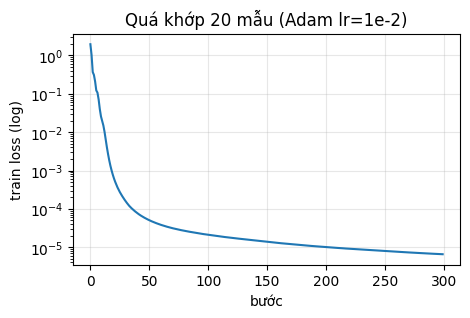

In [6]:
# Phép thử 2: quá khớp 20 mẫu (dropout tắt). Loss phải về gần 0.
set_seed(0)
tiny = MLP(init="he").to(device)
x20, y20 = data["X_tr"][:20], data["y_tr"][:20]
opt = torch.optim.Adam(tiny.parameters(), lr=1e-2)
curve = []
for step in range(300):
    tiny.train()
    loss = F.cross_entropy(tiny(x20), y20)
    opt.zero_grad(); loss.backward(); opt.step()
    curve.append(loss.item())
acc20 = (predict(tiny, x20) == y20).float().mean().item()
print(f"loss cuối = {curve[-1]:.2e}, accuracy trên 20 mẫu = {acc20:.2f}")
assert curve[-1] < 1e-2 and acc20 == 1.0

plt.figure(figsize=(5, 3))
plt.semilogy(curve)
plt.xlabel("bước"); plt.ylabel("train loss (log)"); plt.title("Quá khớp 20 mẫu (Adam lr=1e-2)")
plt.grid(alpha=0.3); plt.show()

In [7]:
# Gradient có chảy tới mọi tham số không?
set_seed(1)
m = MLP(init="he").to(device)
xb, yb = data["X_tr"][:512], data["y_tr"][:512]
F.cross_entropy(m(xb), yb).backward()
for name, p in m.named_parameters():
    g = p.grad
    print(f"{name:14s} shape {str(tuple(p.shape)):12s} ‖grad‖ = {g.norm().item():.4e}")
    assert g is not None and g.norm().item() > 0
print("mọi tham số đều có gradient khác 0")

net.0.weight   shape (256, 54)    ‖grad‖ = 5.0705e-01
net.0.bias     shape (256,)       ‖grad‖ = 3.4224e-01
net.2.weight   shape (128, 256)   ‖grad‖ = 2.0212e+00
net.2.bias     shape (128,)       ‖grad‖ = 4.4387e-01
net.4.weight   shape (7, 128)     ‖grad‖ = 1.9605e+00
net.4.bias     shape (7,)         ‖grad‖ = 5.7246e-01
mọi tham số đều có gradient khác 0


**Nhận xét Part 1:** đúng 47 879 tham số, logits `(B, 7)`. Mô hình học thuộc được 20 mẫu (loss → gần 0, accuracy 100%), nên vòng
forward/backward/cập nhật, nhãn và hàm mất mát không có lỗi. Mọi lớp `W1, b1, W2, b2, W3, b3` đều nhận gradient khác 0.

## Part 2 — Pipeline và baseline
Baseline: `M-base`, He, CE, SGD+momentum 0,9, batch 512, 20 epoch, không dropout/clip, FP32.

Hàm `run()` dưới đây bọc `run_experiment`: lưu `results/<exp_id>.json` và `figures/<exp_id>.png`.
Nếu `results/<exp_id>.json` đã có **với đúng cấu hình đó**, nó đọc lại kết quả thay vì huấn luyện lại (để chạy tiếp được sau khi Colab ngắt).
Trọng số của epoch tốt nhất chỉ lưu (ra `checkpoints/`, ngoài thư mục nộp) cho các cấu hình cần đánh giá trên eval.

In [8]:
RESULTS = {}   # exp_id -> result, theo thứ tự chạy; mỗi phần tử là một dòng của experiments.xlsx


def run(cfg, need_state=False, show=False):
    # mặc định = baseline: lr = BASE_LR (chọn ở 2a bằng val), EPOCHS epoch; cfg chỉ ghi yếu tố bị đổi
    cfg = {**DEFAULT_CFG, "epochs": EPOCHS, "lr": globals().get("BASE_LR"), **cfg}
    exp_id = cfg["exp_id"]
    res_path, ckpt_path = f"{RES_DIR}/{exp_id}.json", f"{CKPT_DIR}/{exp_id}.pt"
    cached = None
    if not RERUN and os.path.exists(res_path) and (not need_state or os.path.exists(ckpt_path)):
        with open(res_path, encoding="utf-8") as f:
            cached = json.load(f)
        if cached["cfg"] != jsonable(cfg):   # cấu hình đã đổi -> chạy lại
            cached = None
    if cached is not None:
        r = cached
        r["cfg"]["hidden"] = tuple(r["cfg"]["hidden"])
        if need_state:
            r["best_state"] = torch.load(ckpt_path, map_location=device)
        s = r["summary"]
        print(f"[{exp_id}] (đọc lại từ results/) best epoch {s['best_epoch']}: val_loss {s['best_val_loss']}  "
              f"val_acc {s['val_acc']}  val_macro_f1 {s['val_macro_f1']}")
    else:
        r = run_experiment(cfg, data)
        save_result(r, RES_DIR)
        if need_state and r["best_state"] is not None:
            torch.save(r["best_state"], ckpt_path)
    fig_path = f"{FIG_DIR}/{exp_id}.png"
    plot_run(r, fig_path)
    if show:
        display(Image(fig_path))
    RESULTS[exp_id] = r
    return r


def f1(exp_id):
    v = RESULTS[exp_id]["summary"]["val_macro_f1"]
    return -1.0 if v is None or (isinstance(v, float) and math.isnan(v)) else v


def table(ids):
    # bảng so sánh với baseline: Δ val macro-F1 so với trung bình baseline, có vượt 2σ không
    rows = []
    for i in ids:
        s, c = RESULTS[i]["summary"], RESULTS[i]["cfg"]
        d = None if f1(i) < 0 else f1(i) - BASE_F1_MEAN
        rows.append(dict(exp_id=i, description=c["description"], val_acc=s["val_acc"], val_macro_f1=s["val_macro_f1"],
                         delta_vs_base=d, beyond_2sigma=None if d is None else ("Có" if abs(d) > NOISE else "Không"),
                         best_epoch=s["best_epoch"], gap_val_train=(s["final_val_loss"] or np.nan) - (s["final_train_loss"] or np.nan),
                         s_per_epoch=s["time_per_epoch_s"], diverged=s["diverged"]))
    return pd.DataFrame(rows).set_index("exp_id").round(4)


def compare(group, ids, metrics=("val_loss", "val_macro_f1", "grad_norm"), title=""):
    path = f"{FIG_DIR}/compare_{group}.png"
    plot_compare([RESULTS[i] for i in ids], list(metrics), path, title or f"So sánh nhóm {group}")
    display(Image(path))

### 2a. Chọn lr cho baseline (bằng val)
Thử `lr ∈ {0.01, 0.03, 0.1}` với SGD+momentum, seed 1, 20 epoch; chọn lr có val macro-F1 cao nhất.
Ba lần chạy này cũng là các dòng của nhóm `optimizer` (SGD+momentum ở 3 lr).

In [9]:
SGDM_LRS = [0.01, 0.03, 0.1]
for lr in SGDM_LRS:
    run(dict(exp_id=f"opt-sgdm-lr{lr:g}", group="optimizer", lr=lr,
             description=f"SGD+momentum 0.9, lr={lr:g} (dò lr cho baseline)"))
lr_scores = {lr: f1(f"opt-sgdm-lr{lr:g}") for lr in SGDM_LRS}
BASE_LR = max(lr_scores, key=lr_scores.get)
print("val macro-F1 theo lr:", {k: round(v, 4) for k, v in lr_scores.items()}, "-> BASE_LR =", BASE_LR)

[opt-sgdm-lr0.01] 47879 tham số, 727 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.5764  val 0.5803  acc 0.7560  F1 0.4941  |g| 0.437 (max 2.84)  1.6s
  ep  2  train 0.5250  val 0.5294  acc 0.7758  F1 0.5824  |g| 0.504 (max 1.09)  1.7s
  ep  3  train 0.4905  val 0.4947  acc 0.7906  F1 0.5968  |g| 0.603 (max 1.43)  1.7s
  ep  4  train 0.4678  val 0.4727  acc 0.8000  F1 0.6280  |g| 0.705 (max 1.57)  1.2s
  ep  5  train 0.4452  val 0.4502  acc 0.8089  F1 0.6427  |g| 0.798 (max 1.73)  1.2s
  ep  6  train 0.4243  val 0.4303  acc 0.8201  F1 0.6656  |g| 0.888 (max 2.18)  1.1s
  ep  7  train 0.4119  val 0.4175  acc 0.8252  F1 0.6798  |g| 0.915 (max 2.41)  1.1s
  ep  8  train 0.4005  val 0.4065  acc 0.8309  F1 0.6791  |g| 1.025 (max 2.17)  1.2s
  ep  9  train 0.3863  val 0.3921  acc 0.8387  F1 0.6941  |g| 1.042 (max 2.26)  1.2s
  ep 10  train 0.3746  val 0.3816  acc 0.8431  F1 0.7180  |g| 1.178 (max 3.14)  1.2s
  ep 11  train 0.3674  val 0.3739  acc 0.8446  F1 0.7131  |g| 1.

### 2b. Baseline với 3 seed (đo độ nhiễu)

[base-s1] 47879 tham số, 727 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.4647  val 0.4675  acc 0.7997  F1 0.6243  |g| 0.530 (max 2.84)  1.1s
  ep  2  train 0.3947  val 0.3996  acc 0.8300  F1 0.7038  |g| 0.567 (max 1.09)  1.2s
  ep  3  train 0.3800  val 0.3862  acc 0.8357  F1 0.7256  |g| 0.564 (max 1.17)  1.1s
  ep  4  train 0.3700  val 0.3800  acc 0.8455  F1 0.7412  |g| 0.575 (max 1.04)  1.1s
  ep  5  train 0.3095  val 0.3204  acc 0.8671  F1 0.7825  |g| 0.572 (max 1.04)  1.3s
  ep  6  train 0.3042  val 0.3151  acc 0.8707  F1 0.7949  |g| 0.587 (max 1.28)  1.3s
  ep  7  train 0.2949  val 0.3047  acc 0.8745  F1 0.7924  |g| 0.580 (max 0.97)  1.5s
  ep  8  train 0.2819  val 0.2936  acc 0.8780  F1 0.7961  |g| 0.571 (max 1.03)  1.1s
  ep  9  train 0.2917  val 0.3068  acc 0.8772  F1 0.8026  |g| 0.575 (max 0.94)  1.2s
  ep 10  train 0.2744  val 0.2900  acc 0.8833  F1 0.8046  |g| 0.579 (max 1.10)  1.2s
  ep 11  train 0.2509  val 0.2629  acc 0.8922  F1 0.8307  |g| 0.563 (max

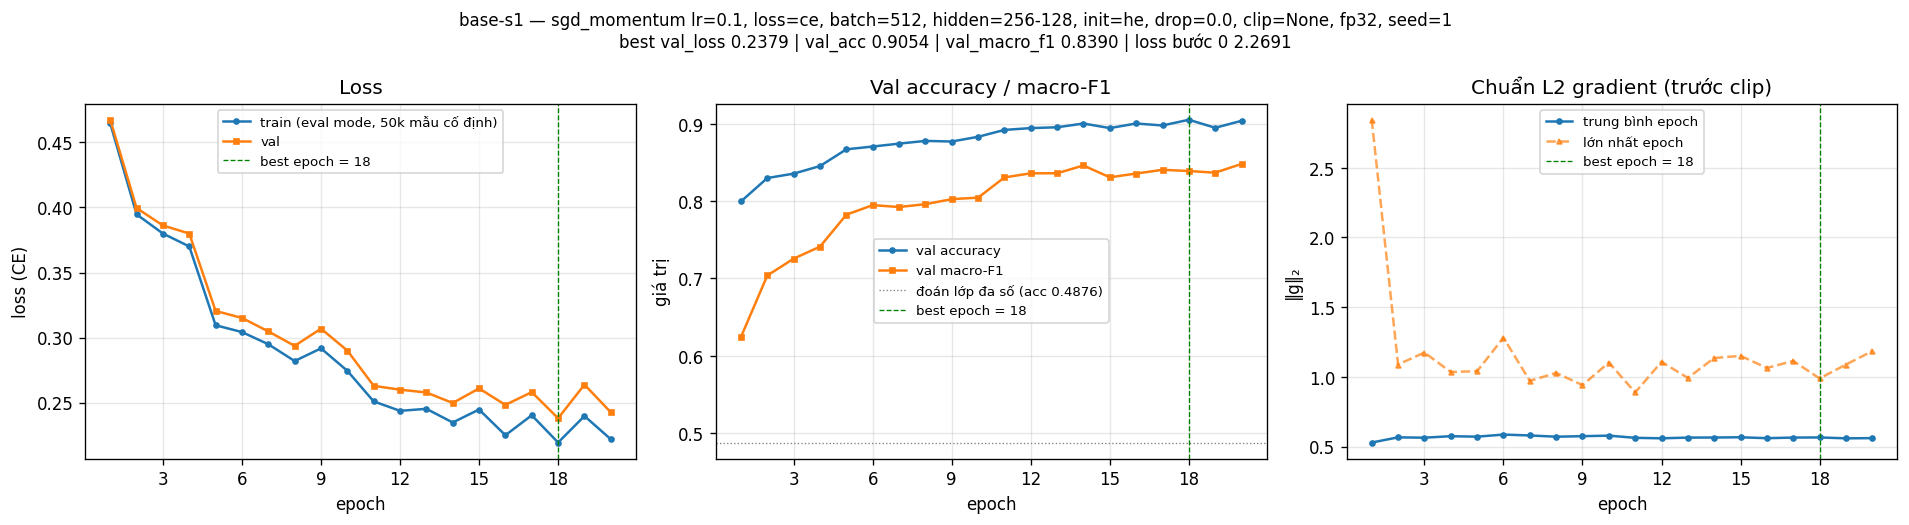

[base-s2] 47879 tham số, 727 bước/epoch, loss bước 0 = 1.9782 (ln 7 = 1.9459)
  ep  1  train 0.4796  val 0.4853  acc 0.7931  F1 0.6686  |g| 0.512 (max 2.07)  1.3s
  ep  2  train 0.3913  val 0.3957  acc 0.8352  F1 0.7242  |g| 0.544 (max 1.07)  1.2s
  ep  3  train 0.3757  val 0.3815  acc 0.8417  F1 0.7437  |g| 0.561 (max 1.15)  1.2s
  ep  4  train 0.3335  val 0.3415  acc 0.8581  F1 0.7608  |g| 0.561 (max 1.05)  1.2s
  ep  5  train 0.3203  val 0.3253  acc 0.8661  F1 0.7700  |g| 0.571 (max 1.12)  1.2s
  ep  6  train 0.3091  val 0.3182  acc 0.8702  F1 0.7734  |g| 0.557 (max 1.21)  1.2s
  ep  7  train 0.2811  val 0.2946  acc 0.8801  F1 0.7986  |g| 0.563 (max 1.07)  1.3s
  ep  8  train 0.2927  val 0.3062  acc 0.8729  F1 0.7958  |g| 0.558 (max 0.88)  1.4s
  ep  9  train 0.2711  val 0.2837  acc 0.8849  F1 0.8163  |g| 0.560 (max 1.14)  1.3s
  ep 10  train 0.2723  val 0.2861  acc 0.8821  F1 0.8053  |g| 0.555 (max 0.96)  1.1s
  ep 11  train 0.2502  val 0.2629  acc 0.8939  F1 0.8356  |g| 0.560 (max

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
base-s1,"Baseline M-base, SGD+momentum lr=0.1, seed 1",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2247,False
base-s2,"Baseline M-base, SGD+momentum lr=0.1, seed 2",0.9100,0.8601,0.0065,Không,19,0.0265,1.2380,False
base-s3,"Baseline M-base, SGD+momentum lr=0.1, seed 3",0.9091,0.8614,0.0079,Không,19,0.0252,1.2218,False


In [10]:
BASE_IDS = [f"base-s{s}" for s in (1, 2, 3)]
for s, i in zip((1, 2, 3), BASE_IDS):
    run(dict(exp_id=i, group="baseline", lr=BASE_LR, seed=s,
             description=f"Baseline M-base, SGD+momentum lr={BASE_LR:g}, seed {s}"),
        need_state=(s == 1), show=(s == 1))

base_f1 = np.array([f1(i) for i in BASE_IDS])
base_acc = np.array([RESULTS[i]["summary"]["val_acc"] for i in BASE_IDS])
BASE_F1_MEAN, BASE_F1_STD = base_f1.mean(), base_f1.std(ddof=1)
NOISE = 2 * BASE_F1_STD
print(f"val macro-F1: {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f}  -> ngưỡng nhiễu 2σ = {NOISE:.4f}")
print(f"val accuracy: {base_acc.mean():.4f} ± {base_acc.std(ddof=1):.4f}")
assert base_acc.min() > 0.4876, "baseline không vượt mốc đoán lớp đa số -> có lỗi"
table(BASE_IDS)

**Nhận xét baseline:**
- **Chọn lr bằng val:** val macro-F1 = 0,761 / 0,817 / 0,839 với lr = 0,01 / 0,03 / 0,1 → `BASE_LR = 0,1`. lr tốt nhất nằm ở **biên** của lưới đã thử, nên có thể lr lớn hơn còn tốt hơn (hạn chế).
- **Hình dạng đường cong (`base-s1`):** val loss giảm nhanh trong 5 epoch đầu (0,468 → 0,320), sau đó chậm dần và dao động nhẹ (0,258 ở epoch 13 và 17, 0,243 ở epoch 20). Best epoch là 18–19/20 ở cả 3 seed → mô hình **chưa hội tụ hẳn**, huấn luyện lâu hơn có thể còn lợi.
- **Chưa quá khớp:** val − train loss ở epoch cuối chỉ 0,021 (train loss đo ở eval mode trên 50k mẫu cố định).
- **So với mốc:** val accuracy 0,905–0,910, vượt xa mốc "đoán lớp đa số" 0,4876.
- **Độ nhiễu 3 seed:** val macro-F1 = 0,8390 / 0,8601 / 0,8614 → **0,8535 ± 0,0126, 2σ = 0,025**; val accuracy 0,9082 ± 0,0024. Macro-F1 dao động nhiều hơn accuracy vì nó nhạy với vài chục mẫu của các lớp hiếm (lớp 3 chỉ có 439 mẫu trong val).
- **Lưu ý khi so sánh:** `base-s1` là seed thấp nhất trong 3 seed, mà mọi thí nghiệm Part 3 dùng seed 1. Các bảng bên dưới so với **trung bình** baseline (thận trọng); chênh lệch < 2σ coi là chưa kết luận được.

## Part 3 — Thí nghiệm
Mỗi thí nghiệm đổi **một** yếu tố so với `base-s1` (cùng seed 1, cùng split, 20 epoch). Dự đoán viết **trước** khi chạy; đối chiếu viết sau.
Cột `beyond_2sigma` so chênh lệch val macro-F1 với ngưỡng nhiễu 2σ của baseline.

### Chủ đề 1 — Hàm mất mát: CE vs MSE (nhóm `loss`)
MSE tính như `nn.MSELoss`: trung bình trên mọi phần tử `(B·7)` giữa logit thô và one-hot, không có hệ số 1/2.

**Dự đoán:** MSE học chậm hơn và macro-F1 thấp hơn CE ở cùng lr. Gradient của CE theo logit là `p − y`, không bão hoà khi dự đoán sai nặng;
gradient MSE theo logit là `2(z − y)/7` (do lấy trung bình trên 7 cột) nên nhỏ hơn nhiều và không gắn với xác suất. Lớp hiếm bị ảnh hưởng nhiều nhất.
Thử thêm lr ×3 để xem chênh lệch có phải chỉ do độ lớn gradient. So bằng accuracy/macro-F1, không so loss (khác thang đo).

[loss-mse-lr0.1] 47879 tham số, 727 bước/epoch, loss bước 0 = 0.6359 (ln 7 = 1.9459)
  ep  1  train 0.0483  val 0.0485  acc 0.7645  F1 0.4526  |g| 0.060 (max 2.26)  1.5s
  ep  2  train 0.0442  val 0.0444  acc 0.7885  F1 0.5179  |g| 0.056 (max 0.11)  1.2s
  ep  3  train 0.0415  val 0.0419  acc 0.8006  F1 0.5270  |g| 0.064 (max 0.16)  1.3s
  ep  4  train 0.0398  val 0.0403  acc 0.8134  F1 0.5785  |g| 0.072 (max 0.16)  1.2s
  ep  5  train 0.0380  val 0.0385  acc 0.8198  F1 0.6164  |g| 0.077 (max 0.14)  1.2s
  ep  6  train 0.0365  val 0.0372  acc 0.8282  F1 0.6302  |g| 0.081 (max 0.16)  1.3s
  ep  7  train 0.0354  val 0.0360  acc 0.8345  F1 0.6578  |g| 0.083 (max 0.18)  1.3s
  ep  8  train 0.0344  val 0.0350  acc 0.8411  F1 0.6758  |g| 0.087 (max 0.15)  1.2s
  ep  9  train 0.0337  val 0.0343  acc 0.8442  F1 0.6635  |g| 0.089 (max 0.17)  1.3s
  ep 10  train 0.0329  val 0.0335  acc 0.8491  F1 0.6930  |g| 0.092 (max 0.17)  1.4s
  ep 11  train 0.0324  val 0.0330  acc 0.8523  F1 0.6931  |g| 0.0

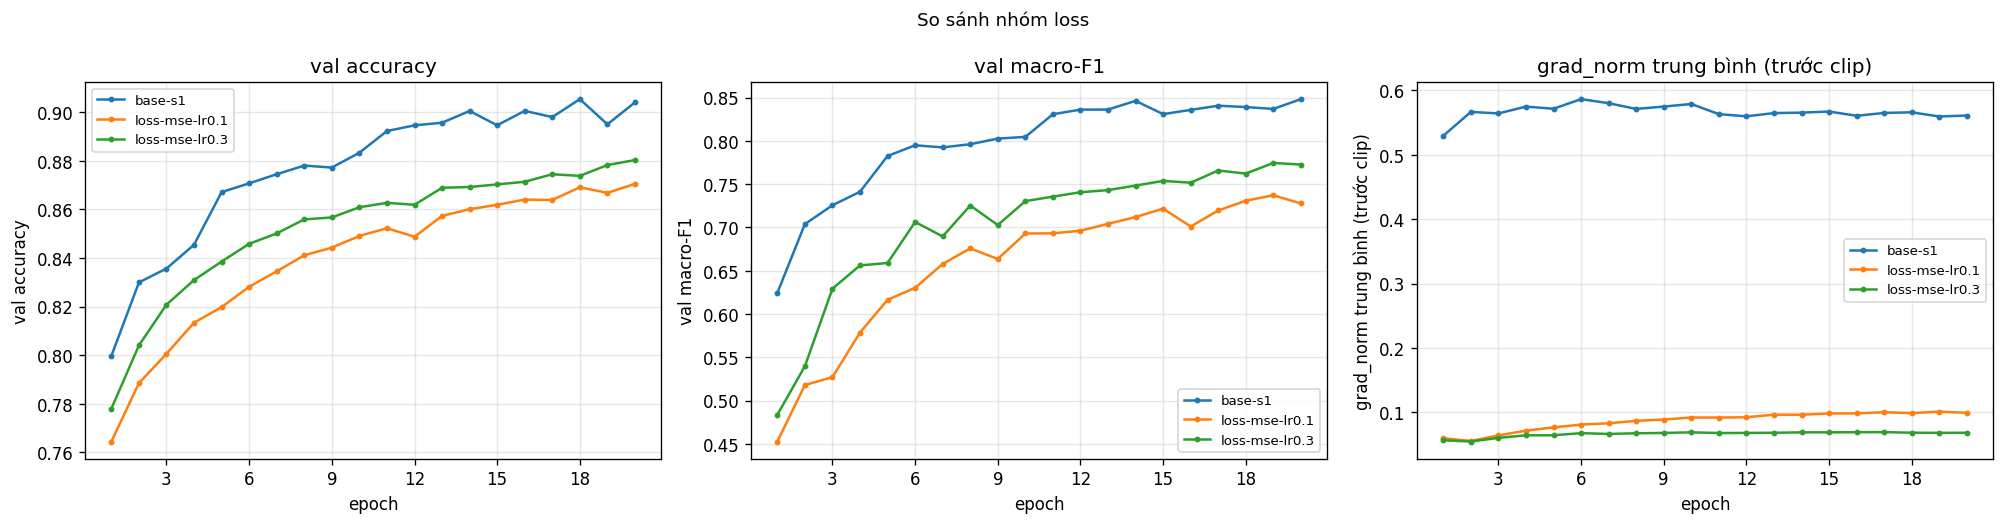

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
base-s1,"Baseline M-base, SGD+momentum lr=0.1, seed 1",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2247,False
loss-mse-lr0.1,"MSE trên one-hot thay CE, lr=0.1",0.8705,0.7277,-0.1258,Có,20,0.0009,1.2842,False
loss-mse-lr0.3,"MSE trên one-hot thay CE, lr=0.3",0.8803,0.7726,-0.0809,Có,20,0.0010,1.3297,False


In [11]:
LOSS_IDS = []
for mult in (1, 3):
    lr = BASE_LR * mult
    i = f"loss-mse-lr{lr:g}"
    run(dict(exp_id=i, group="loss", loss="mse", lr=lr, description=f"MSE trên one-hot thay CE, lr={lr:g}"))
    LOSS_IDS.append(i)
compare("loss", ["base-s1"] + LOSS_IDS, metrics=("val_acc", "val_macro_f1", "grad_norm"))
table(["base-s1"] + LOSS_IDS)

**Đối chiếu (loss):** **khớp dự đoán.**
- MSE kém CE rõ rệt: val macro-F1 0,728 (`loss-mse-lr0.1`, Δ −0,126) và 0,773 (`loss-mse-lr0.3`, Δ −0,081) so với baseline 0,854; cả hai **vượt 2σ** (0,025).
- Gradient nhỏ hơn nhiều: trung vị ‖g‖ của MSE là 0,085 / 0,065, so với 0,55 của CE (nhỏ hơn 6–8 lần).
- Tăng lr ×3 thu hẹp khoảng cách được một phần (0,728 → 0,773), nên một phần nguyên nhân là **độ lớn gradient**. Nhưng vẫn kém CE 0,08, và best epoch = 20 ở cả hai (vẫn đang học chậm).
- Cơ chế: gradient của CE theo logit là `p − y`. Nó không bão hoà khi mô hình sai nặng, và gắn trực tiếp với xác suất của lớp đúng. MSE ép logit thô tiến về đúng 0/1 trên cả 7 cột, phạt cả dự đoán đúng nhưng "quá tự tin"; mỗi phần tử còn bị chia 7 do lấy trung bình. Các lớp hiếm đóng góp rất ít vào tổng nên học chậm nhất.
- Không so giá trị loss (MSE 0,027 so với CE 0,24): hai loss khác thang đo.

### Chủ đề 2 — Bộ tối ưu hoá (nhóm `optimizer`)
Mỗi bộ tối ưu thử ≥ 2 lr, so ở lr tốt nhất của nó. SGD+momentum đã có 3 lr ở Part 2a.
SGD thuần: lr lớn hơn (momentum 0,9 tương đương nhân bước hiệu dụng ×10). Adam/AdamW: `betas=(0.9, 0.999)`, `eps=1e-8`; AdamW `weight_decay=0.01`.

**Dự đoán:** SGD thuần ở cùng số epoch sẽ kém SGD+momentum nếu lr nhỏ; với lr ×10 thì gần bằng.
Adam hội tụ nhanh hơn ở các epoch đầu (bước chia theo √v̂ từng tham số, ít nhạy với độ lớn gradient), ở lr tốt nhất có thể nhỉnh hơn SGD+momentum
nhưng chênh lệch có thể không vượt 2σ. AdamW với wd nhỏ gần như giống Adam vì mô hình chưa quá khớp.

[opt-sgd-lr0.3] 47879 tham số, 727 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.5338  val 0.5351  acc 0.7688  F1 0.5273  |g| 0.567 (max 2.84)  1.5s
  ep  2  train 0.4821  val 0.4840  acc 0.7936  F1 0.6337  |g| 0.584 (max 1.40)  1.2s
  ep  3  train 0.4634  val 0.4674  acc 0.8054  F1 0.6168  |g| 0.599 (max 1.52)  1.1s
  ep  4  train 0.5371  val 0.5446  acc 0.7680  F1 0.6530  |g| 0.627 (max 1.66)  1.1s
  ep  5  train 0.4102  val 0.4143  acc 0.8232  F1 0.6814  |g| 0.649 (max 1.66)  1.1s
  ep  6  train 0.3859  val 0.3931  acc 0.8364  F1 0.7236  |g| 0.645 (max 1.65)  1.1s
  ep  7  train 0.4932  val 0.4986  acc 0.7812  F1 0.6718  |g| 0.652 (max 1.80)  1.2s
  ep  8  train 0.4014  val 0.4081  acc 0.8303  F1 0.6653  |g| 0.667 (max 1.67)  1.1s
  ep  9  train 0.3391  val 0.3473  acc 0.8571  F1 0.7094  |g| 0.667 (max 1.77)  1.2s
  ep 10  train 0.3939  val 0.4004  acc 0.8270  F1 0.6948  |g| 0.689 (max 1.49)  1.2s
  ep 11  train 0.3552  val 0.3600  acc 0.8473  F1 0.7613  |g| 0.67

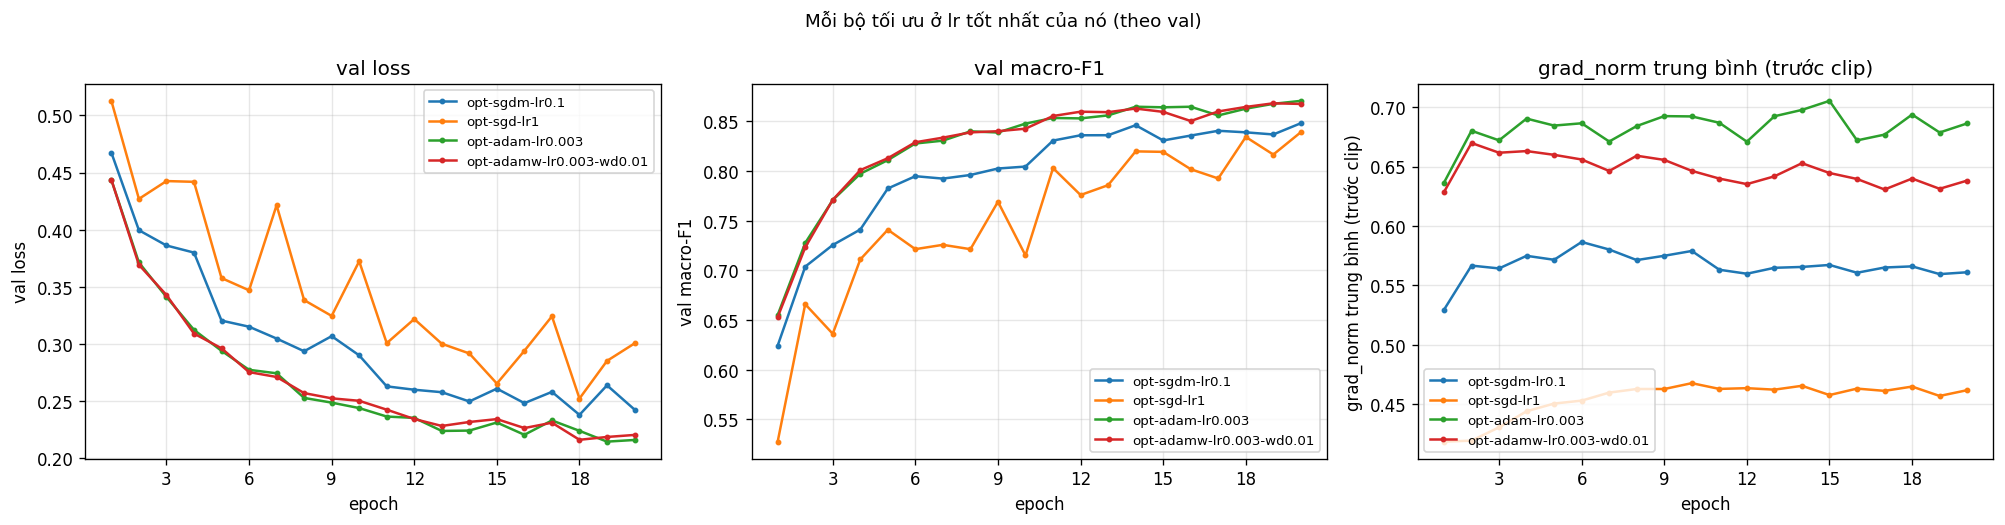

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
opt-sgdm-lr0.01,"SGD+momentum 0.9, lr=0.01 (dò lr cho baseline)",0.8747,0.7613,-0.0923,Có,20,0.0115,1.3240,False
opt-sgdm-lr0.03,"SGD+momentum 0.9, lr=0.03 (dò lr cho baseline)",0.8921,0.8170,-0.0366,Có,20,0.0187,1.2503,False
opt-sgdm-lr0.1,"SGD+momentum 0.9, lr=0.1 (dò lr cho baseline)",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2227,False
opt-sgd-lr0.3,"SGD thuần (không momentum), lr=0.3",0.8871,0.8163,-0.0372,Có,18,0.0131,1.2685,False
opt-sgd-lr1,"SGD thuần (không momentum), lr=1",0.9000,0.8344,-0.0191,Không,18,0.0246,1.2345,False
opt-adam-lr0.0003,"Adam, lr=0.0003",0.8727,0.7877,-0.0658,Có,20,0.0104,1.3643,False
opt-adam-lr0.001,"Adam, lr=0.001",0.8993,0.8456,-0.0080,Không,19,0.0203,1.4086,False
opt-adam-lr0.003,"Adam, lr=0.003",0.9153,0.8677,0.0142,Không,19,0.0290,1.3786,False
opt-adamw-lr0.001-wd0.01,"AdamW, lr=0.001, weight_decay=0.01",0.9004,0.8482,-0.0053,Không,20,0.0189,1.3816,False


In [12]:
OPT_IDS = [f"opt-sgdm-lr{lr:g}" for lr in SGDM_LRS]
for lr in (BASE_LR * 3, BASE_LR * 10):
    i = f"opt-sgd-lr{lr:g}"
    run(dict(exp_id=i, group="optimizer", optimizer="sgd", lr=lr, description=f"SGD thuần (không momentum), lr={lr:g}"))
    OPT_IDS.append(i)
for lr in (3e-4, 1e-3, 3e-3):
    i = f"opt-adam-lr{lr:g}"
    run(dict(exp_id=i, group="optimizer", optimizer="adam", lr=lr, description=f"Adam, lr={lr:g}"))
    OPT_IDS.append(i)
for lr in (1e-3, 3e-3):
    i = f"opt-adamw-lr{lr:g}-wd0.01"
    run(dict(exp_id=i, group="optimizer", optimizer="adamw", lr=lr, weight_decay=0.01,
             description=f"AdamW, lr={lr:g}, weight_decay=0.01"))
    OPT_IDS.append(i)

best_per_opt = {}
for i in OPT_IDS:
    name = RESULTS[i]["cfg"]["optimizer"]
    if name not in best_per_opt or f1(i) > f1(best_per_opt[name]):
        best_per_opt[name] = i
print("lr tốt nhất (theo val macro-F1) của mỗi bộ tối ưu:", best_per_opt)
compare("optimizer", list(best_per_opt.values()), title="Mỗi bộ tối ưu ở lr tốt nhất của nó (theo val)")
table(OPT_IDS)

**Đối chiếu (optimizer):** mỗi bộ tối ưu ở lr tốt nhất của nó (theo val):

| bộ tối ưu | lr tốt nhất | val macro-F1 | Δ so với TB baseline | vượt 2σ? |
|---|---|---|---|---|
| SGD+momentum 0,9 | 0,1 | 0,839 (seed 1) | −0,015 | không |
| SGD thuần | 1,0 | 0,834 | −0,019 | không |
| Adam | 0,003 | 0,868 | +0,014 | không |
| AdamW (wd 0,01) | 0,003 | 0,865 | +0,011 | không |

- **Một phần khớp dự đoán.** Adam hội tụ nhanh hơn ở các epoch đầu: F1 ở epoch 1 / 5 / 10 là 0,655 / 0,811 / 0,848, so với SGD+momentum 0,624 / 0,782 / 0,805. Adam cũng cao nhất ở epoch 20. Nhưng ở lr tốt nhất của mỗi bộ, **chênh lệch không vượt 2σ** → chưa thể nói Adam thắng chắc chắn. So cùng seed 1, Adam hơn `base-s1` +0,029, chỉ nhỉnh hơn ngưỡng.
- **Nhạy với lr:** cả 4 bộ đều cho lr tốt nhất ở **đầu trên** của lưới (SGD+m 0,761 → 0,839; Adam 0,788 → 0,868 khi lr tăng ×10). Nếu không chỉnh lr công bằng, kết luận có thể đảo ngược: Adam lr 3e-4 (0,788) thua SGD+m lr 0,1 (0,839), còn Adam lr 3e-3 lại thắng SGD+m lr 0,01 (0,761) tới 0,107.
- **SGD thuần cần lr ×10** mới bằng SGD+momentum (0,834 so với 0,839). Đúng với bước hiệu dụng `η/(1−μ) = 10η` của momentum 0,9. Đường SGD thuần cũng dao động hơn (epoch 10 tụt còn 0,715).
- **Adam ≈ AdamW** ở cả hai lr (0,846 / 0,848 và 0,868 / 0,865). wd = 0,01 gần như không tác dụng vì mô hình chưa quá khớp.

### Chủ đề 3 — Hyper-parameter (nhóm `hparam`)
- Batch 128 và 2048 (cùng lr): cùng 20 epoch nhưng số bước cập nhật lần lượt ×4 và ÷4 so với batch 512.
- Batch 2048 với lr ×4 + khởi động 1 epoch (quy tắc "lô ×k thì η ×k"; đổi 3 thứ cùng lúc, có ghi rõ).
- `M-wide` (512-256, 161 287 tham số) và `M-deep` (256-128-64, 55 687 tham số).

**Dự đoán:** batch 2048 cùng lr kém rõ (ít bước hơn 4 lần); tăng lr ×4 kéo lại phần lớn. Batch 128 tốt hơn một chút nhưng chậm hơn mỗi epoch.
Mô hình rộng/sâu hơn có val macro-F1 cao hơn vì baseline ở 20 epoch chưa quá khớp (bài toán cần nhiều năng lực để phân biệt các lớp hiếm).

[hp-batch128] 47879 tham số, 2906 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.4385  val 0.4406  acc 0.8120  F1 0.6527  |g| 0.585 (max 2.99)  4.5s
  ep  2  train 0.3667  val 0.3739  acc 0.8445  F1 0.7205  |g| 0.592 (max 1.22)  4.7s
  ep  3  train 0.3345  val 0.3403  acc 0.8610  F1 0.7735  |g| 0.594 (max 2.65)  5.0s
  ep  4  train 0.3017  val 0.3147  acc 0.8732  F1 0.7944  |g| 0.594 (max 0.96)  4.8s
  ep  5  train 0.2756  val 0.2898  acc 0.8824  F1 0.8047  |g| 0.592 (max 3.46)  4.8s
  ep  6  train 0.2756  val 0.2882  acc 0.8818  F1 0.8053  |g| 0.594 (max 1.46)  5.0s
  ep  7  train 0.2651  val 0.2787  acc 0.8856  F1 0.8045  |g| 0.591 (max 5.22)  4.5s
  ep  8  train 0.2493  val 0.2654  acc 0.8927  F1 0.8268  |g| 0.588 (max 1.06)  4.8s
  ep  9  train 0.2429  val 0.2602  acc 0.8949  F1 0.8202  |g| 0.584 (max 0.99)  4.8s
  ep 10  train 0.2514  val 0.2651  acc 0.8922  F1 0.8212  |g| 0.582 (max 1.70)  4.6s
  ep 11  train 0.2362  val 0.2556  acc 0.8968  F1 0.8345  |g| 0.579

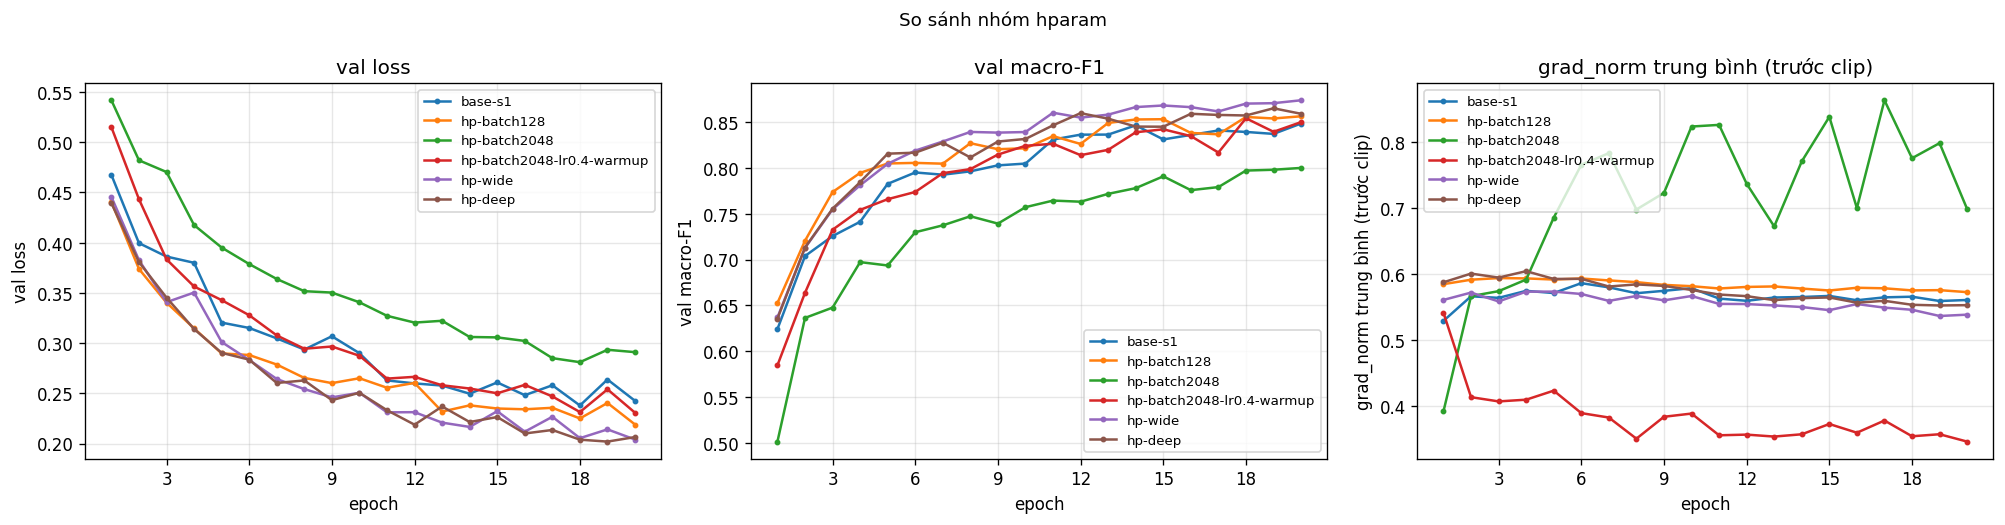

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
base-s1,"Baseline M-base, SGD+momentum lr=0.1, seed 1",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2247,False
hp-batch128,batch 128 (lr giữ nguyên 0.1),0.9130,0.8561,0.0026,Không,20,0.0268,4.7648,False
hp-batch2048,batch 2048 (lr giữ nguyên 0.1),0.8852,0.7970,-0.0565,Có,18,0.0172,0.3104,False
hp-batch2048-lr0.4-warmup,"batch 2048, lr ×4 = 0.4, khởi động tuyến tính ...",0.9074,0.8497,-0.0038,Không,20,0.0220,0.3401,False
hp-wide,M-wide: hidden=512-256,0.9197,0.8735,0.0200,Không,20,0.0325,1.2781,False
hp-deep,M-deep: hidden=256-128-64,0.9200,0.8648,0.0113,Không,19,0.0266,1.4120,False


In [13]:
HP_IDS = []
for b in (128, 2048):
    i = f"hp-batch{b}"
    run(dict(exp_id=i, group="hparam", batch=b, lr=BASE_LR, description=f"batch {b} (lr giữ nguyên {BASE_LR:g})"))
    HP_IDS.append(i)
steps_2048 = math.ceil(len(data["X_tr"]) / 2048)
i = f"hp-batch2048-lr{BASE_LR * 4:g}-warmup"
run(dict(exp_id=i, group="hparam", batch=2048, lr=BASE_LR * 4, scheduler="warmup", warmup_steps=steps_2048,
         description=f"batch 2048, lr ×4 = {BASE_LR * 4:g}, khởi động tuyến tính 1 epoch ({steps_2048} bước)"))
HP_IDS.append(i)
for name, hidden in (("wide", (512, 256)), ("deep", (256, 128, 64))):
    i = f"hp-{name}"
    run(dict(exp_id=i, group="hparam", hidden=hidden, description=f"M-{name}: hidden={'-'.join(map(str, hidden))}"))
    HP_IDS.append(i)
compare("hparam", ["base-s1"] + HP_IDS)
table(["base-s1"] + HP_IDS)

**Đối chiếu (hyper-parameter):**
- **Batch 2048 cùng lr** kém rõ: 0,797 (Δ −0,057, **vượt 2σ**). Lý do: cùng 20 epoch nhưng chỉ có 182 bước/epoch (3 640 bước tổng), so với 727 (14 540 bước) ở batch 512 → **ít hơn 4 lần số lần cập nhật**. Khớp dự đoán.
- **Batch 2048, lr ×4 + khởi động 1 epoch:** 0,850 (Δ −0,004, trong nhiễu). Quy tắc "lô ×k thì η ×k" **bù gần hết** số bước bị mất, mà chỉ mất 0,34 s/epoch, nhanh gấp 3,6 lần baseline (1,22 s). (Thí nghiệm này đổi 3 thứ cùng lúc: batch, lr, warmup.)
- **Batch 128:** 0,856 (Δ +0,003, trong nhiễu) với 4 lần số bước, nhưng chậm gấp 3,9 lần (4,76 s/epoch). Thời gian/epoch gần như tỉ lệ với **số bước**, không phải số mẫu: mạng nhỏ nên chi phí mỗi bước bị chi phối bởi việc gọi kernel.
- **M-wide:** 0,8735 (Δ +0,020). **M-deep:** 0,865 (Δ +0,011). Cả hai **chưa vượt 2σ**, nhưng đều tăng và có val loss thấp hơn rõ (0,204 / 0,207 so với 0,243). Khoảng cách val − train của M-wide tăng lên 0,033 (mô hình nhiều năng lực hơn). Khớp hướng dự đoán, nhưng độ lớn chưa đủ để kết luận khi chỉ chạy 1 seed.

### Chủ đề 4 — Dropout (nhóm `dropout`)
q ∈ {0,1; 0,3}, đặt sau ReLU của hai lớp ẩn. train loss đo ở `eval()` nên so sánh được với val loss.

**Dự đoán:** baseline 20 epoch có khoảng cách val − train loss rất nhỏ (chưa quá khớp, 370k mẫu so với 48k tham số), nên dropout
không có gì để chữa: nó thêm nhiễu và giảm năng lực hiệu dụng, val macro-F1 giảm, q = 0,3 giảm nhiều hơn q = 0,1.

[drop-0.1] 47879 tham số, 727 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.4820  val 0.4850  acc 0.7914  F1 0.5866  |g| 0.396 (max 2.90)  1.2s
  ep  2  train 0.4248  val 0.4290  acc 0.8182  F1 0.6770  |g| 0.366 (max 0.60)  1.3s
  ep  3  train 0.3877  val 0.3919  acc 0.8357  F1 0.7159  |g| 0.374 (max 0.77)  1.3s
  ep  4  train 0.3603  val 0.3645  acc 0.8482  F1 0.7406  |g| 0.376 (max 0.73)  1.3s
  ep  5  train 0.3430  val 0.3498  acc 0.8533  F1 0.7492  |g| 0.378 (max 0.65)  1.5s
  ep  6  train 0.3301  val 0.3364  acc 0.8606  F1 0.7698  |g| 0.382 (max 0.80)  1.6s
  ep  7  train 0.3190  val 0.3252  acc 0.8653  F1 0.7752  |g| 0.388 (max 0.82)  1.5s
  ep  8  train 0.3036  val 0.3119  acc 0.8711  F1 0.7888  |g| 0.384 (max 0.75)  1.3s
  ep  9  train 0.2921  val 0.2993  acc 0.8771  F1 0.7940  |g| 0.383 (max 0.64)  1.3s
  ep 10  train 0.2918  val 0.3004  acc 0.8772  F1 0.8013  |g| 0.386 (max 0.68)  1.3s
  ep 11  train 0.2832  val 0.2909  acc 0.8790  F1 0.8002  |g| 0.385 (ma

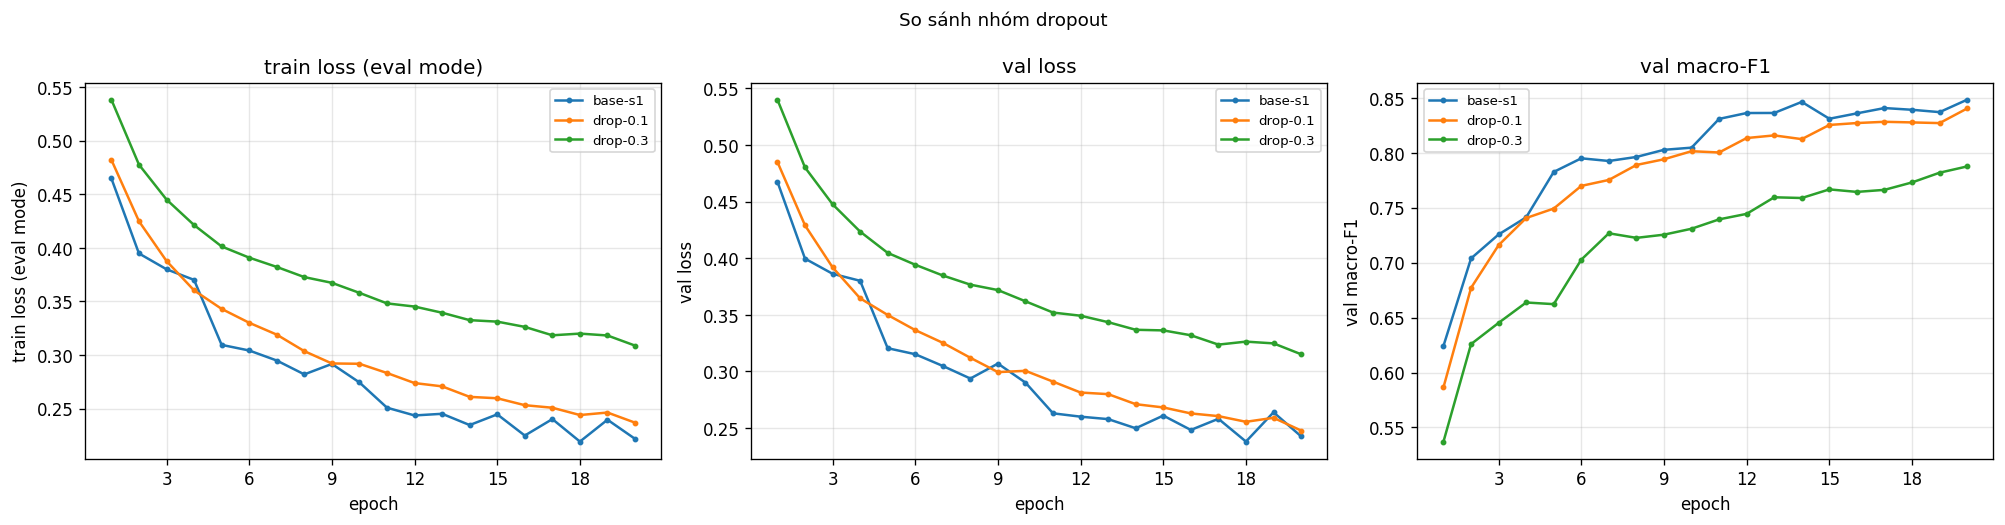

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
base-s1,"Baseline M-base, SGD+momentum lr=0.1, seed 1",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2247,False
drop-0.1,dropout q=0.1 sau mỗi ReLU ẩn,0.9005,0.8402,-0.0133,Không,20,0.0108,1.3656,False
drop-0.3,dropout q=0.3 sau mỗi ReLU ẩn,0.8728,0.7875,-0.0660,Có,20,0.0063,1.3564,False


In [14]:
DROP_IDS = []
for q in (0.1, 0.3):
    i = f"drop-{q:g}"
    run(dict(exp_id=i, group="dropout", dropout=q, description=f"dropout q={q:g} sau mỗi ReLU ẩn"))
    DROP_IDS.append(i)
compare("dropout", ["base-s1"] + DROP_IDS, metrics=("train_loss", "val_loss", "val_macro_f1"))
table(["base-s1"] + DROP_IDS)

**Đối chiếu (dropout):** **khớp dự đoán.**
- Baseline chưa quá khớp: val − train loss ở epoch cuối chỉ 0,021.
- Dropout thu hẹp khoảng cách đó (0,011 với q = 0,1; 0,006 với q = 0,3), nhưng là do **train loss tăng** (năng lực hiệu dụng giảm), không phải val loss giảm: val loss lần lượt 0,248 và 0,315, so với 0,243 của baseline.
- val macro-F1: q = 0,1 → 0,840 (Δ −0,013, trong nhiễu); q = 0,3 → 0,788 (Δ −0,066, **vượt 2σ**, tệ hơn).
- Best epoch = 20 ở cả hai: học chậm hơn.
- Kết luận: dropout là thuốc cho quá khớp. Mô hình này đang thiếu năng lực/thời gian huấn luyện chứ không quá khớp, nên dropout chỉ làm hại.

### Chủ đề 5 — Gradient clipping (nhóm `clipping`)
`g ← g · min(1, c/‖g‖)` với chuẩn L2 toàn cục. **c chọn từ `grad_norm` của baseline:** c = trung vị ‖g‖ của `base-s1`, để clip thực sự
kích hoạt ở khoảng một nửa số bước.
Thí nghiệm phản chứng: tăng lr (×10, ×30, ×100) cho tới khi huấn luyện không clip hỏng (NaN hoặc macro-F1 sụt mạnh), rồi chạy lại đúng lr đó có clip.

**Dự đoán:** ở lr bình thường, clip với c = trung vị gần như không đổi kết quả (chỉ thu nhỏ bước khi gradient lớn; SGD+momentum vẫn đi đúng hướng).
Ở lr cao, không clip thì loss nổ; có clip thì độ dài mỗi bước bị chặn ở lr·c nên huấn luyện ổn định hơn, dù chưa chắc bằng baseline.

grad_norm của base-s1: trung vị 0.550, p90 0.696 -> c = 0.55
[clip-c0.55] 47879 tham số, 727 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.4523  val 0.4547  acc 0.8045  F1 0.6284  |g| 0.561 (max 2.84)  1.1s
  ep  2  train 0.3888  val 0.3942  acc 0.8353  F1 0.7103  |g| 0.628 (max 1.20)  1.2s
  ep  3  train 0.3732  val 0.3815  acc 0.8399  F1 0.7302  |g| 0.621 (max 1.17)  1.2s
  ep  4  train 0.3576  val 0.3684  acc 0.8490  F1 0.7506  |g| 0.647 (max 1.45)  1.4s
  ep  5  train 0.3271  val 0.3376  acc 0.8601  F1 0.7738  |g| 0.638 (max 1.28)  1.3s
  ep  6  train 0.3023  val 0.3137  acc 0.8710  F1 0.7954  |g| 0.642 (max 1.28)  1.4s
  ep  7  train 0.2973  val 0.3092  acc 0.8712  F1 0.7948  |g| 0.628 (max 1.18)  1.1s
  ep  8  train 0.2733  val 0.2869  acc 0.8838  F1 0.8141  |g| 0.634 (max 1.22)  1.2s
  ep  9  train 0.2637  val 0.2782  acc 0.8862  F1 0.8154  |g| 0.632 (max 1.10)  1.2s
  ep 10  train 0.2790  val 0.2937  acc 0.8794  F1 0.8067  |g| 0.636 (max 1.17)  1.2s
  ep 11 

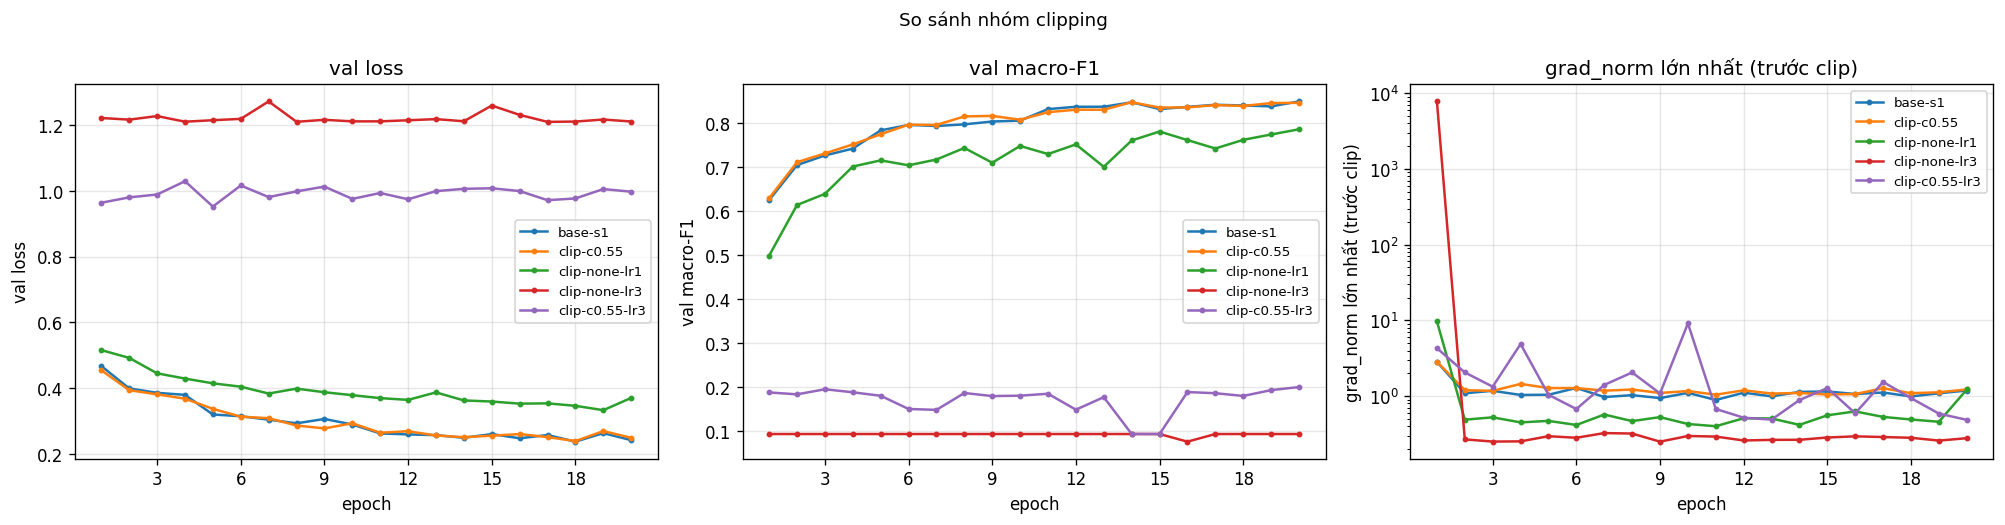

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
base-s1,"Baseline M-base, SGD+momentum lr=0.1, seed 1",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2247,False
clip-c0.55,"clip c=0.55 (trung vị grad_norm baseline), lr=0.1",0.9036,0.8380,-0.0155,Không,18,0.0252,1.2405,False
clip-none-lr1,"KHÔNG clip, lr cao = 1 (×10)",0.8662,0.7732,-0.0803,Có,19,0.0186,1.2507,False
clip-none-lr3,"KHÔNG clip, lr cao = 3 (×30)",0.4876,0.0936,-0.7599,Có,17,0.0018,1.2694,False
clip-c0.55-lr3,clip c=0.55 ở lr cao = 3,0.5084,0.1804,-0.6731,Có,5,0.0037,1.2643,False


In [15]:
s1 = RESULTS["base-s1"]["summary"]
C = float(f"{s1['grad_norm_median']:.2g}")
print(f"grad_norm của base-s1: trung vị {s1['grad_norm_median']:.3f}, p90 {s1['grad_norm_p90']:.3f} -> c = {C:g}")

CLIP_IDS = [f"clip-c{C:g}"]
run(dict(exp_id=CLIP_IDS[0], group="clipping", lr=BASE_LR, clip_norm=C, description=f"clip c={C:g} (trung vị grad_norm baseline), lr={BASE_LR:g}"))

HIGH_LR = None
for mult in (10, 30, 100):
    lr = BASE_LR * mult
    i = f"clip-none-lr{lr:g}"
    r = run(dict(exp_id=i, group="clipping", lr=lr, description=f"KHÔNG clip, lr cao = {lr:g} (×{mult})"))
    CLIP_IDS.append(i)
    if r["summary"]["diverged"] or f1(i) < BASE_F1_MEAN - 0.1:
        HIGH_LR = lr
        break
if HIGH_LR is None:
    print("Không lr nào trong ×10..×100 làm hỏng huấn luyện; dùng lr ×100 cho phép thử có clip.")
    HIGH_LR = BASE_LR * 100
i = f"clip-c{C:g}-lr{HIGH_LR:g}"
run(dict(exp_id=i, group="clipping", lr=HIGH_LR, clip_norm=C, description=f"clip c={C:g} ở lr cao = {HIGH_LR:g}"))
CLIP_IDS.append(i)
for i in CLIP_IDS:
    print(f"{i:24s} tỉ lệ bước bị clip = {RESULTS[i]['summary']['clip_frac']:.2%}")
compare("clipping", ["base-s1"] + CLIP_IDS, metrics=("val_loss", "val_macro_f1", "grad_norm_max"))
table(["base-s1"] + CLIP_IDS)

**Đối chiếu (clipping):**
- **Ở lr thường (0,1):** c = 0,55 (trung vị ‖g‖ của `base-s1`; p90 = 0,70). Clip kích hoạt ở **72%** số bước, nhưng F1 = 0,838 so với 0,839 của `base-s1` cùng seed → **không khác**. Khớp dự đoán: ‖g‖ của baseline ổn định (không có gai sau epoch 1), clip chỉ thu nhỏ độ dài bước một chút mà không đổi hướng.
- **Ở lr ×10 (1,0), không clip:** chưa ra NaN nhưng F1 tụt còn 0,773 (Δ −0,081), ‖g‖ lớn nhất trong epoch 1 = 9,7.
- **Ở lr ×30 (3,0), không clip:** ‖g‖ lớn nhất trong epoch 1 = **7 814**, sau đó ‖g‖ sụt về ~0,08. F1 = 0,094 và acc = 0,4876 trong suốt 20 epoch: mô hình **sụp về "đoán lớp đa số"**. Loss không thành NaN, nên cờ `diverged` không bật; hỏng kiểu "chết" chứ không nổ số.
- **Ở lr ×30, có clip (c = 0,55):** gai bị chặn (‖g‖ lớn nhất 4,3, clip kích hoạt 10% bước ở epoch 1, sau đó ~1%), nhưng F1 chỉ 0,18–0,20 → **clip không cứu được**. **Khác dự đoán.**
- Giải thích: clip chặn độ dài mỗi bước ở `lr·c = 1,65`, vẫn lớn hơn rất nhiều so với độ lớn trọng số (std của W1 theo He ≈ 0,19). Vài bước đầu vẫn đủ phá mạng; sau đó gradient nhỏ nên clip không còn kích hoạt. Phỏng đoán (chưa đo trực tiếp) là phần lớn nơ-ron ReLU đã "chết" (luôn âm), thể hiện ở ‖g‖ rất nhỏ.
- Bài học: clipping chữa các **gai hiếm** của gradient, không chữa được một lr **quá lớn một cách hệ thống**.

### Chủ đề 6 — Mixed precision (nhóm `amp`)
FP16: `autocast(float16)` + `GradScaler` (unscale trước khi đo/cắt gradient). BF16: `autocast(bfloat16)`, không GradScaler.
Tham số vẫn FP32; chỉ phép toán trong forward hạ độ chính xác. Cần GPU CUDA.

**Dự đoán:** độ chính xác gần như không đổi (trong 2σ). Mô hình rất nhỏ (48k tham số, lô 512) nên thời gian bị chi phối bởi chi phí gọi kernel,
mixed precision khó nhanh hơn, có thể còn chậm hơn vì thêm phép ép kiểu và GradScaler. BF16 trên T4 không có phần cứng hỗ trợ nên có thể chậm.
FP16 cần nhân loss với hệ số s vì khoảng biểu diễn hẹp (nhỏ nhất ~6e-8, gradient nhỏ bị làm tròn về 0);
BF16 có cùng 8 bit mũ như FP32 nên không bị underflow, chỉ kém chính xác phần định trị.

[amp-fp16] 47879 tham số, 727 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.4675  val 0.4696  acc 0.7992  F1 0.6225  |g| 0.531 (max 2.84)  1.7s
  ep  2  train 0.3937  val 0.3975  acc 0.8324  F1 0.7020  |g| 0.566 (max 1.09)  1.7s
  ep  3  train 0.3775  val 0.3828  acc 0.8384  F1 0.7287  |g| 0.562 (max 1.09)  1.6s
  ep  4  train 0.3845  val 0.3943  acc 0.8368  F1 0.7327  |g| 0.572 (max 1.06)  1.6s
  ep  5  train 0.3137  val 0.3234  acc 0.8652  F1 0.7801  |g| 0.567 (max 1.02)  1.7s
  ep  6  train 0.2990  val 0.3101  acc 0.8734  F1 0.7965  |g| 0.585 (max 1.26)  2.0s
  ep  7  train 0.2948  val 0.3050  acc 0.8749  F1 0.7986  |g| 0.571 (max 1.13)  2.0s
  ep  8  train 0.2743  val 0.2882  acc 0.8816  F1 0.8011  |g| 0.567 (max 1.04)  1.7s
  ep  9  train 0.2713  val 0.2870  acc 0.8816  F1 0.8121  |g| 0.568 (max 0.90)  1.7s
  ep 10  train 0.2804  val 0.2973  acc 0.8796  F1 0.8083  |g| 0.573 (max 1.07)  1.7s
  ep 11  train 0.2555  val 0.2713  acc 0.8892  F1 0.8287  |g| 0.561 (ma

,s_per_epoch,peak_mem_MB,val_macro_f1,amp_skipped_steps
exp_id,,,,
base-s1,1.2247,173.9126,0.8390,0
amp-fp16,1.7560,173.9116,0.8484,4
amp-bf16,1.5217,173.9106,0.8469,0


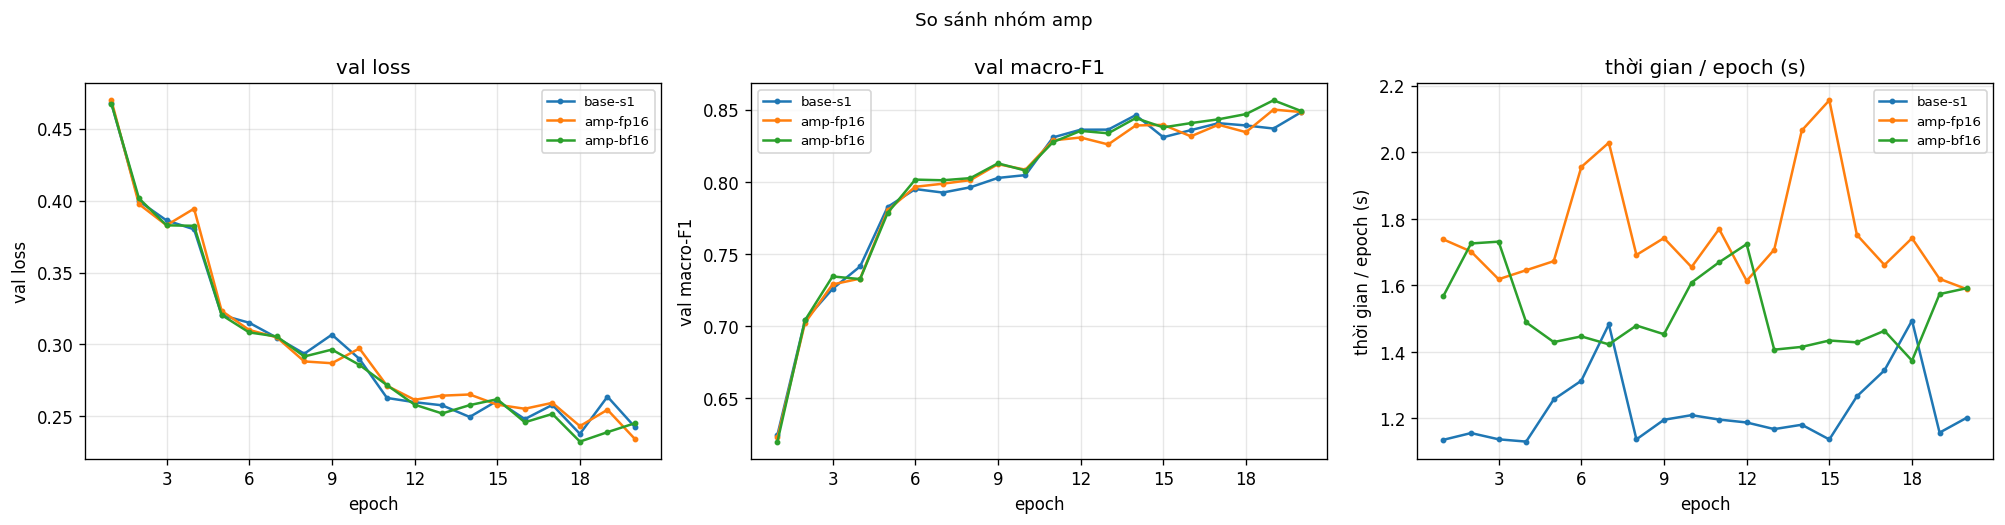

In [16]:
AMP_IDS = []
if device == "cuda":
    for prec in ("fp16", "bf16"):
        i = f"amp-{prec}"
        run(dict(exp_id=i, group="amp", precision=prec, description=f"mixed precision {prec}"
                 + (" + GradScaler" if prec == "fp16" else "")))
        AMP_IDS.append(i)
    rows = []
    for i in ["base-s1"] + AMP_IDS:
        s = RESULTS[i]["summary"]
        rows.append(dict(exp_id=i, s_per_epoch=s["time_per_epoch_s"], peak_mem_MB=s["peak_mem_MB"],
                         val_macro_f1=s["val_macro_f1"], amp_skipped_steps=s["amp_skipped_steps"]))
    display(pd.DataFrame(rows).set_index("exp_id").round(4))
    compare("amp", ["base-s1"] + AMP_IDS, metrics=("val_loss", "val_macro_f1", "epoch_time_s"))
else:
    print("Không có GPU CUDA: bỏ qua mixed precision (chạy notebook trên Colab GPU để có chủ đề này).")

**Đối chiếu (mixed precision, T4):**

| | s/epoch | bộ nhớ cực đại (MB) | val macro-F1 |
|---|---|---|---|
| FP32 (`base-s1`) | 1,22 | 173,9 | 0,839 |
| BF16 (`amp-bf16`) | 1,52 | 173,9 | 0,847 |
| FP16 + GradScaler (`amp-fp16`) | 1,76 | 173,9 | 0,848 |

- **Khớp dự đoán.** Độ chính xác không đổi (Δ so với `base-s1` < 0,01, trong nhiễu). Mixed precision **chậm hơn** (BF16 +24%, FP16 +44%) và **không tiết kiệm bộ nhớ**.
- Lý do: mạng rất nhỏ (ma trận lớn nhất 256 × 128, lô 512). Thời gian mỗi bước bị chi phối bởi chi phí gọi kernel, còn autocast thêm các kernel ép kiểu, FP16 thêm bước scale/unscale/kiểm tra inf của GradScaler.
- Bộ nhớ cực đại gần như toàn bộ là dữ liệu nằm sẵn trên GPU (581 012 × 54 × 4 B ≈ 125 MB); kích hoạt chỉ vài MB nên hạ độ chính xác không thấy được.
- GradScaler bỏ qua 4 bước (tràn số khi hệ số scale ban đầu 65 536 còn quá lớn). Đây là cơ chế bình thường của FP16: FP16 chỉ có 5 bit mũ, giá trị nhỏ nhất ~6e-8, nên loss phải nhân với `s` để gradient nhỏ không bị làm tròn về 0. BF16 có 8 bit mũ như FP32 nên không cần.
- T4 (kiến trúc Turing) không có phần cứng BF16 (`is_bf16_supported()` vẫn trả True), nên BF16 không có lợi về tốc độ trên GPU này.

### Chủ đề 7 — Khởi tạo tham số (nhóm `init`)
`zeros` (W = 0), `normal` (N(0, 0,01²)), `xavier` (`xavier_normal_`, Var = 2/(n_in + n_out)), `he` (baseline, Var = 2/n_in), `default` (mặc định `nn.Linear`). Bias = 0 (trừ `default`).

**Dự đoán:** `zeros`: mọi nơ-ron trong một lớp giống hệt nhau và ReLU(0) = 0 nên gradient của W1, W2 bằng 0, chỉ bias lớp cuối học được →
mô hình chỉ học được tần suất lớp, kẹt ở mức "đoán lớp đa số" (acc ≈ 0,4876). `normal(0,01)`: kích hoạt teo dần qua các lớp, ban đầu học chậm
nhưng 3 lớp vẫn đủ nông để hồi phục. `xavier`/`default` gần He vì mạng chỉ có 2 lớp ẩn; khác biệt rõ chỉ thấy ở mạng sâu.

,relu1,relu2,logits,step0_loss
zeros,0.0000,0.0000,0.0000,1.9459
normal,0.0203,0.0022,0.0003,1.9460
xavier,0.1628,0.1248,0.1916,2.0222
default,0.1603,0.0678,0.0585,1.9830
he,0.3901,0.3661,0.5773,2.2691


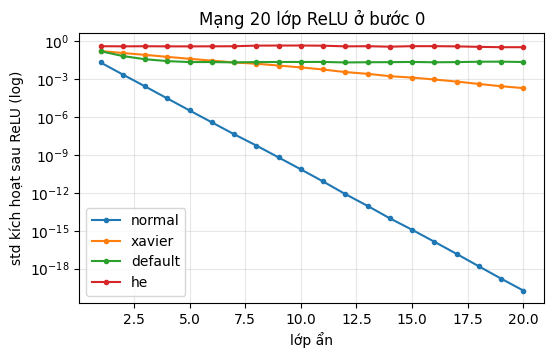

In [17]:
# std của kích hoạt sau mỗi ReLU (và của logits) ở bước 0, trên một lô val 4096 mẫu
xb = data["X_val"][:4096]
rows = {}
for init in ["zeros", "normal", "xavier", "default", "he"]:
    set_seed(1)
    m = MLP(init=init).to(device)
    stds = activation_stats(m, xb)
    rows[init] = dict(relu1=stds[0], relu2=stds[1], logits=stds[2],
                      step0_loss=evaluate(m, data["X_val"], data["y_val"])["loss"])
display(pd.DataFrame(rows).T.round(4))

# Minh hoạ thêm (không phải thí nghiệm huấn luyện, không vào bảng): mạng 20 lớp ẩn 256
depth_stats = {}
for init in ["normal", "xavier", "default", "he"]:
    set_seed(1)
    depth_stats[init] = activation_stats(MLP(hidden=(256,) * 20, init=init).to(device), xb)[:-1]
plt.figure(figsize=(6, 3.5))
for init, s in depth_stats.items():
    plt.semilogy(range(1, 21), s, "o-", ms=3, label=init)
plt.xlabel("lớp ẩn"); plt.ylabel("std kích hoạt sau ReLU (log)"); plt.title("Mạng 20 lớp ReLU ở bước 0")
plt.legend(); plt.grid(alpha=0.3); plt.show()

[init-zeros] 47879 tham số, 727 bước/epoch, loss bước 0 = 1.9459 (ln 7 = 1.9459)
  ep  1  train 1.2035  val 1.2054  acc 0.4876  F1 0.0936  |g| 0.042 (max 0.50)  1.2s
  ep  2  train 1.2036  val 1.2053  acc 0.4876  F1 0.0936  |g| 0.034 (max 0.10)  1.2s
  ep  3  train 1.2036  val 1.2054  acc 0.4876  F1 0.0936  |g| 0.035 (max 0.11)  1.1s
  ep  4  train 1.2035  val 1.2052  acc 0.4876  F1 0.0936  |g| 0.034 (max 0.15)  1.2s
  ep  5  train 1.2035  val 1.2053  acc 0.4876  F1 0.0936  |g| 0.034 (max 0.11)  1.2s
  ep  6  train 1.2035  val 1.2053  acc 0.4876  F1 0.0936  |g| 0.032 (max 0.11)  1.2s
  ep  7  train 1.2034  val 1.2052  acc 0.4876  F1 0.0936  |g| 0.034 (max 0.10)  1.1s
  ep  8  train 1.2039  val 1.2056  acc 0.4876  F1 0.0936  |g| 0.034 (max 0.11)  1.2s
  ep  9  train 1.2039  val 1.2057  acc 0.4876  F1 0.0936  |g| 0.034 (max 0.12)  1.4s
  ep 10  train 1.2035  val 1.2052  acc 0.4876  F1 0.0936  |g| 0.034 (max 0.10)  1.4s
  ep 11  train 1.2034  val 1.2052  acc 0.4876  F1 0.0936  |g| 0.033 (

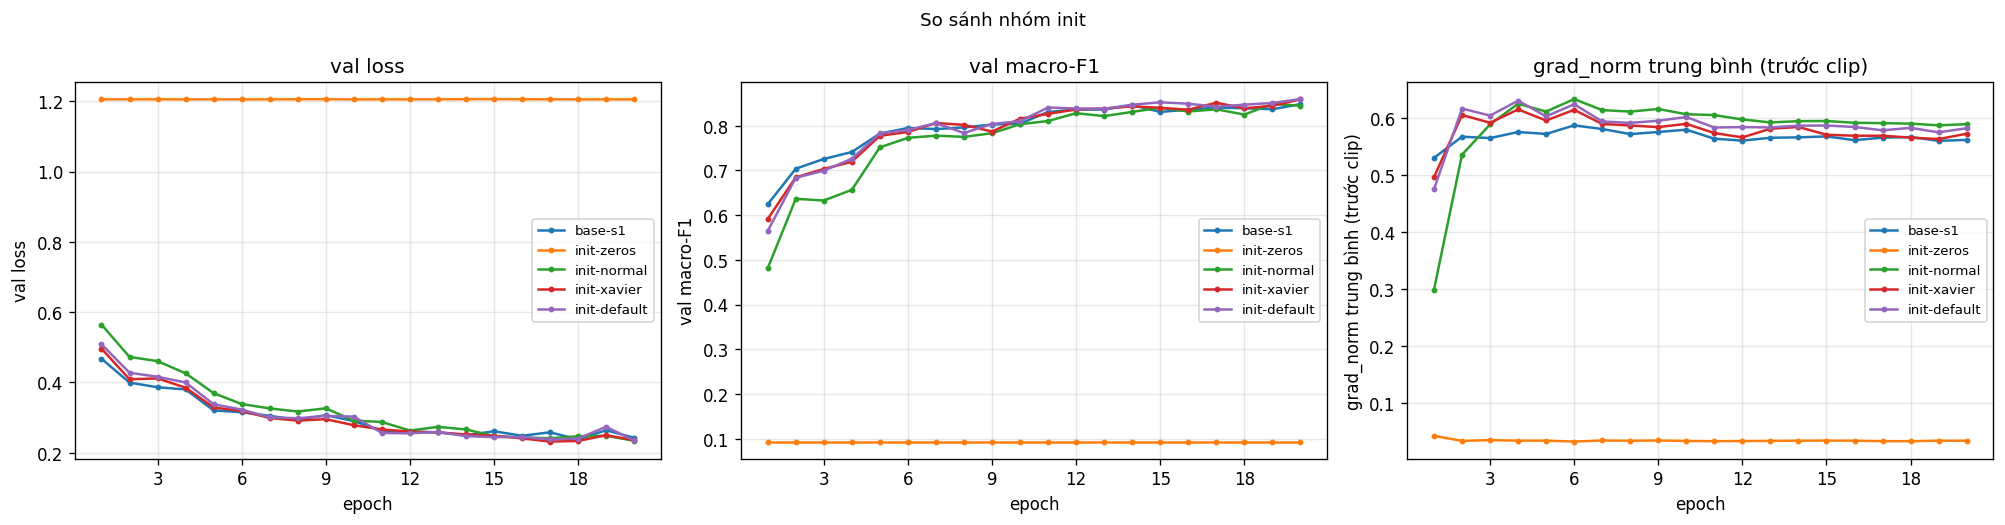

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
base-s1,"Baseline M-base, SGD+momentum lr=0.1, seed 1",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2247,False
init-zeros,khởi tạo zeros thay cho He,0.4876,0.0936,-0.7599,Có,10,0.0018,1.2174,False
init-normal,khởi tạo normal thay cho He,0.9046,0.8449,-0.0086,Không,20,0.0236,1.2248,False
init-xavier,khởi tạo xavier thay cho He,0.9072,0.8514,-0.0021,Không,17,0.0223,1.2385,False
init-default,khởi tạo default thay cho He,0.9058,0.8595,0.0059,Không,20,0.0196,1.2743,False


In [18]:
INIT_IDS = []
for init in ("zeros", "normal", "xavier", "default"):
    i = f"init-{init}"
    run(dict(exp_id=i, group="init", init=init, description=f"khởi tạo {init} thay cho He"))
    INIT_IDS.append(i)
compare("init", ["base-s1"] + INIT_IDS)
table(["base-s1"] + INIT_IDS)

**Đối chiếu (init):**
- **`zeros` khớp dự đoán:** acc = 0,4876 và F1 = 0,094 không đổi suốt 20 epoch (= đoán lớp đa số), ‖g‖ chỉ ~0,03. Cơ chế: W1 = W2 = 0 và bias = 0 nên mọi kích hoạt ẩn = ReLU(0) = 0. Gradient của W3 bằng 0 (vì đầu vào của nó bằng 0); gradient truyền ngược về lớp ẩn cũng bằng 0 (vì W3 = 0). Chỉ bias lớp cuối học được → mô hình chỉ học được tần suất lớp. Đối xứng không bao giờ bị phá.
- **Loss bước 0** (bảng ở trên): zeros/normal cho 1,946 ≈ ln 7 (logits ≈ 0). He cho 2,27 vì std logits = 0,58. Loss bước 0 "đẹp" **không** đảm bảo mô hình học được (zeros là ví dụ).
- **`normal(0,01)`:** std kích hoạt sau ReLU thứ hai chỉ 0,002 ở bước 0 (teo dần), nhưng mạng 3 lớp vẫn hồi phục: F1 0,845 (Δ −0,009).
- **`xavier` 0,851, `default` 0,860, He (TB baseline) 0,854:** chênh nhau **trong 2σ**. Mạng 2 lớp ẩn **chưa đủ sâu** để thấy khác biệt.
- **Mạng 20 lớp** (hình trên, chỉ minh hoạ, không huấn luyện): std kích hoạt sau ReLU ở lớp 1 → lớp 20 là:
  - normal: 2e-2 → 2e-20 (biến mất hoàn toàn)
  - xavier: 0,17 → 2e-4 (std giảm ~√2 lần mỗi lớp, vì Var = 2/(n_in + n_out) = 1/n_in khi n_in = n_out, bằng một nửa mức ReLU cần)
  - He: giữ ổn định 0,33–0,45 (đúng như slide)
  - default: dừng ở ~0,02 (phỏng đoán: do bias mặc định khác 0 giữ một mức sàn).

## Part 3b — Cấu hình cuối cùng (chọn bằng val)
Ứng viên: bộ tối ưu tốt nhất theo val ở Part 3, huấn luyện 40 epoch (baseline vẫn còn giảm ở epoch 20), và cùng cấu hình đó với `M-wide`.
Chọn ứng viên có val macro-F1 cao nhất (so cả với `base-s1`), rồi chạy thêm 2 seed để đo nhiễu của cấu hình cuối.

bộ tối ưu tốt nhất theo val: opt-adam-lr0.003 {'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0}
[final-ep40-s1] 47879 tham số, 727 bước/epoch, loss bước 0 = 2.2691 (ln 7 = 1.9459)
  ep  1  train 0.4409  val 0.4436  acc 0.8104  F1 0.6551  |g| 0.636 (max 2.84)  1.3s
  ep  2  train 0.3672  val 0.3713  acc 0.8435  F1 0.7276  |g| 0.680 (max 1.65)  1.4s
  ep  3  train 0.3347  val 0.3411  acc 0.8572  F1 0.7708  |g| 0.672 (max 1.50)  1.5s
  ep  4  train 0.3023  val 0.3123  acc 0.8733  F1 0.7974  |g| 0.690 (max 1.89)  1.7s
  ep  5  train 0.2805  val 0.2940  acc 0.8786  F1 0.8111  |g| 0.684 (max 1.57)  1.4s
  ep  6  train 0.2660  val 0.2774  acc 0.8858  F1 0.8278  |g| 0.686 (max 1.58)  1.3s
  ep  7  train 0.2597  val 0.2743  acc 0.8867  F1 0.8307  |g| 0.671 (max 1.58)  1.3s
  ep  8  train 0.2362  val 0.2528  acc 0.8976  F1 0.8400  |g| 0.684 (max 1.52)  1.4s
  ep  9  train 0.2318  val 0.2486  acc 0.8988  F1 0.8389  |g| 0.692 (max 1.54)  1.3s
  ep 10  train 0.2251  val 0.2439  acc 0.9015  F1

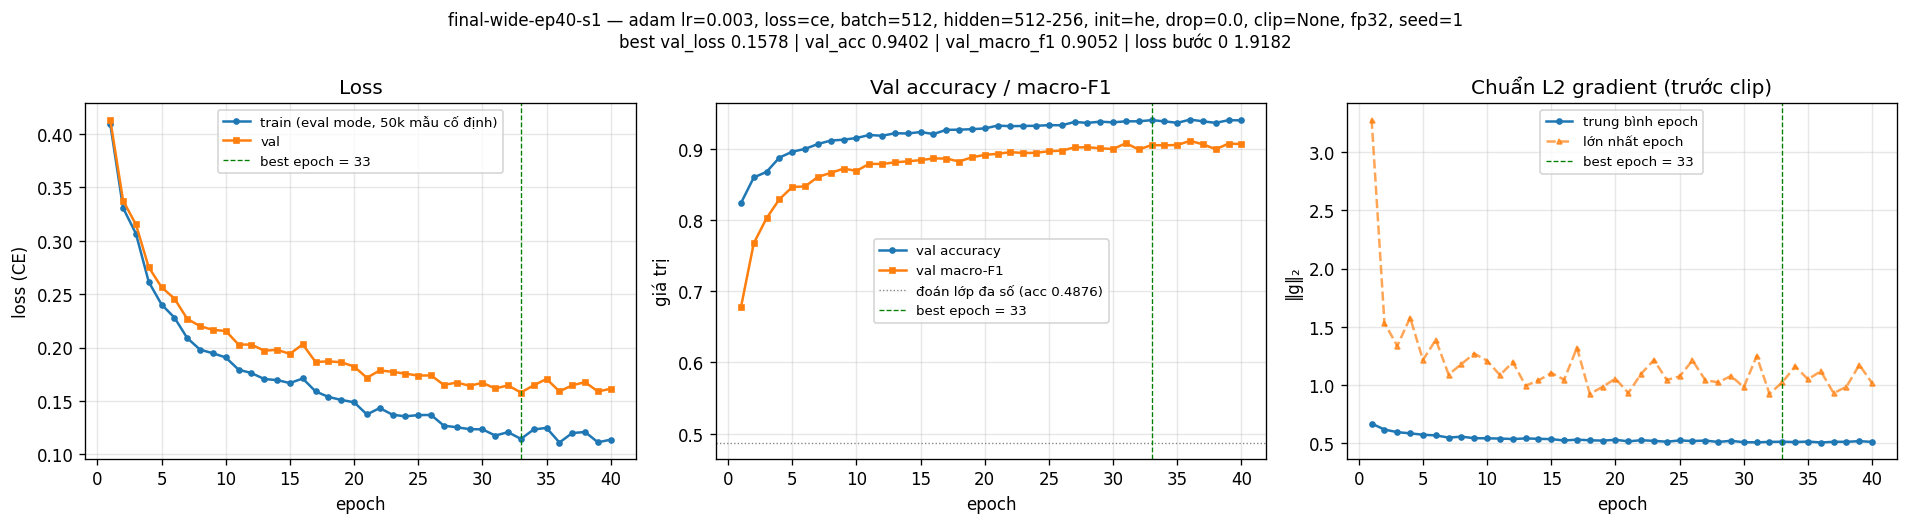

,description,val_acc,val_macro_f1,delta_vs_base,beyond_2sigma,best_epoch,gap_val_train,s_per_epoch,diverged
exp_id,,,,,,,,,
base-s1,"Baseline M-base, SGD+momentum lr=0.1, seed 1",0.9054,0.8390,-0.0145,Không,18,0.0207,1.2247,False
final-ep40-s1,opt-adam-lr0.003 + hidden=256-128 + 40 epoch,0.9285,0.8894,0.0359,Có,38,0.0392,1.3967,False
final-wide-ep40-s1,opt-adam-lr0.003 + hidden=512-256 + 40 epoch,0.9402,0.9052,0.0517,Có,33,0.0477,1.4414,False
final-wide-ep40-s2,"opt-adam-lr0.003 + hidden=512-256 + 40 epoch, ...",0.9411,0.9080,0.0545,Có,38,0.0512,1.4299,False
final-wide-ep40-s3,"opt-adam-lr0.003 + hidden=512-256 + 40 epoch, ...",0.9417,0.9112,0.0577,Có,39,0.0490,1.4155,False


In [19]:
best_opt_id = max(OPT_IDS, key=f1)
bc = RESULTS[best_opt_id]["cfg"]
opt_keys = dict(optimizer=bc["optimizer"], lr=bc["lr"], weight_decay=bc["weight_decay"])
print("bộ tối ưu tốt nhất theo val:", best_opt_id, opt_keys)

FINAL_EPOCHS = 2 * EPOCHS
CANDIDATES = {
    "final-ep40": dict(hidden=(256, 128)),
    "final-wide-ep40": dict(hidden=(512, 256)),
}
for name, extra in CANDIDATES.items():
    run(dict(exp_id=f"{name}-s1", group="final", epochs=FINAL_EPOCHS, seed=1, **opt_keys, **extra,
             description=f"{best_opt_id} + hidden={'-'.join(map(str, extra['hidden']))} + {FINAL_EPOCHS} epoch"),
        need_state=True)

pool = ["base-s1"] + [f"{n}-s1" for n in CANDIDATES]
FINAL_ID = max(pool, key=f1)
print("cấu hình cuối cùng (theo val):", FINAL_ID, f"val macro-F1 = {f1(FINAL_ID):.4f}")

FINAL_SEED_IDS = [FINAL_ID]
if FINAL_ID != "base-s1":
    fc = RESULTS[FINAL_ID]["cfg"]
    for s in (2, 3):
        i = FINAL_ID.replace("-s1", f"-s{s}")
        run({**fc, "exp_id": i, "seed": s, "description": fc["description"] + f", seed {s}"})
        FINAL_SEED_IDS.append(i)
    ff = np.array([f1(i) for i in FINAL_SEED_IDS])
    print(f"cấu hình cuối, val macro-F1 qua {len(ff)} seed: {ff.mean():.4f} ± {ff.std(ddof=1):.4f}"
          f"  (baseline {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f})")
display(Image(f"{FIG_DIR}/{FINAL_ID}.png"))
table(pool + FINAL_SEED_IDS[1:])

## Part 4 — Đánh giá cuối trên eval, phân tích lỗi, bảng
Cấu hình đã chốt ở trên bằng val. Bây giờ mới dùng eval, **mỗi mô hình một lần**: `base-s1` và cấu hình cuối (seed 1), bằng trọng số của epoch
có val loss thấp nhất. Điểm do `scripts/evaluate.py` tính. Không quay lại chỉnh cấu hình sau bước này.

In [20]:
EVAL_SCORES = {}
targets = {"base-s1": (f"{RES_DIR}/base-s1_predictions_eval.csv", f"{RES_DIR}/base-s1_eval_result.json")}
targets[FINAL_ID] = (f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json")  # file nộp (ghi đè nếu FINAL_ID là base-s1)

for exp_id, (pred_path, json_path) in targets.items():
    r = RESULTS[exp_id]
    if "best_state" not in r:  # kết quả đọc lại từ results/: nạp trọng số
        r["best_state"] = torch.load(f"{CKPT_DIR}/{exp_id}.pt", map_location=device)
    print(f"===== {exp_id} =====")
    if FAST:   # chạy thử pipeline: chỉ ghi file dự đoán, KHÔNG chấm điểm eval
        final_eval(r["cfg"], r, data, pred_path)
        continue
    EVAL_SCORES[exp_id] = final_eval(r["cfg"], r, data, pred_path, repo_root=REPO_ROOT, out_json=json_path)

===== base-s1 =====
đã ghi ../results/base-s1_predictions_eval.csv (116203 dòng)
n_eval = 116203
accuracy = 0.9033
macro_f1 = 0.8410   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9016  0.9029  0.9022
  1    56661     0.9093  0.9304  0.9197
  2     7151     0.8972  0.8839  0.8905
  3      549     0.7618  0.7923  0.7768
  4     1899     0.8161  0.6403  0.7176
  5     3473     0.8489  0.7328  0.7866
  6     4102     0.9436  0.8484  0.8935

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38255   3897     0    0    23     5   188
1   3557  52719    84    1   191    89    20
2      4    359  6321   88    48   331     0
3      0      0    92  435     0    22     0
4     64    600    13    0  1216     6     0
5      9    325   535   47    12  2545     0
6    543     79     0    0     0     0  3480

đã ghi /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602630/results/base-s1_eval_result.json

=====

final-wide-ep40-s1: eval accuracy = 0.9394, eval macro-F1 = 0.9072
base-s1 : eval accuracy = 0.9033, eval macro-F1 = 0.8410


,tên,support,precision,recall,f1
cls,,,,,
0,Spruce/Fir,42368,0.9398,0.9334,0.9366
1,Lodgepole Pine,56661,0.9453,0.9515,0.9484
2,Ponderosa Pine,7151,0.9504,0.9291,0.9396
3,Cottonwood/Willow,549,0.8470,0.8470,0.8470
4,Aspen,1899,0.8436,0.8462,0.8449
5,Douglas-fir,3473,0.8641,0.9171,0.8898
6,Krummholz,4102,0.9609,0.9278,0.9441


lớp khó nhất: 4 (Aspen), F1 = 0.8449; hay bị nhầm nhất sang lớp 1 (Lodgepole Pine, 12.4% số mẫu của lớp)


,đoán 0,đoán 1,đoán 2,đoán 3,đoán 4,đoán 5,đoán 6
thật 0,39548,2666,1,0,29,9,115
thật 1,2233,53911,101,0,237,139,40
thật 2,0,113,6644,63,25,306,0
thật 3,0,0,52,465,0,32,0
thật 4,32,236,9,0,1607,15,0
thật 5,1,75,184,21,7,3185,0
thật 6,266,30,0,0,0,0,3806


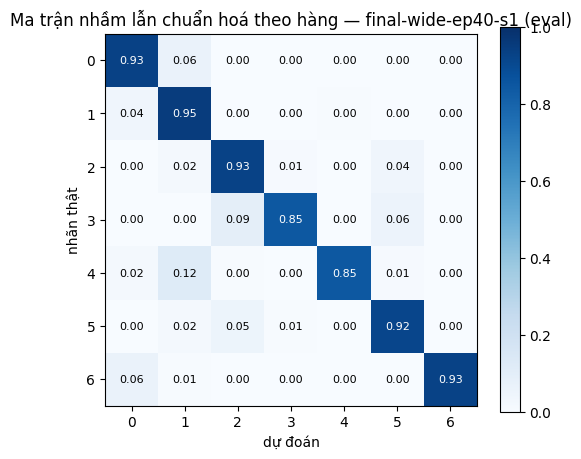

In [21]:
# Phân tích lỗi theo lớp cho cấu hình cuối (số từ eval_result.json)
CLASS_NAMES = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]
if not FAST:
    res = EVAL_SCORES[FINAL_ID]
    per = pd.DataFrame(res["per_class"]).set_index("cls")
    per.insert(0, "tên", CLASS_NAMES)
    print(f"{FINAL_ID}: eval accuracy = {res['accuracy']:.4f}, eval macro-F1 = {res['macro_f1']:.4f}")
    b = EVAL_SCORES["base-s1"]
    print(f"base-s1 : eval accuracy = {b['accuracy']:.4f}, eval macro-F1 = {b['macro_f1']:.4f}")
    display(per.round(4))

    cm = np.array(res["confusion_matrix"])
    cm_norm = cm / cm.sum(1, keepdims=True)
    off = cm_norm.copy(); np.fill_diagonal(off, 0)
    hardest = int(per["f1"].idxmin())
    print(f"lớp khó nhất: {hardest} ({CLASS_NAMES[hardest]}), F1 = {per.loc[hardest, 'f1']:.4f}; "
          f"hay bị nhầm nhất sang lớp {off[hardest].argmax()} ({CLASS_NAMES[off[hardest].argmax()]}, "
          f"{off[hardest].max():.1%} số mẫu của lớp)")
    display(pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"đoán {c}" for c in range(7)]))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for a in range(7):
        for c in range(7):
            ax.text(c, a, f"{cm_norm[a, c]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cm_norm[a, c] > 0.5 else "black")
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật")
    ax.set_title(f"Ma trận nhầm lẫn chuẩn hoá theo hàng — {FINAL_ID} (eval)")
    fig.colorbar(im); plt.show()

**Phân tích lỗi (cấu hình cuối `final-wide-ep40-s1`, eval):**
- **Lớp khó nhất:** lớp 4 Aspen (F1 0,845) và lớp 3 Cottonwood/Willow (F1 0,847). Đây cũng là hai lớp ít mẫu nhất trong train: 6 075 và 1 759 mẫu (1,6% và 0,5%).
- **Aspen** bị nhầm sang Lodgepole Pine (lớp 1) **12,4%** số mẫu (236/1 899). Đo trên train: độ cao (Elevation) của Aspen 2 674–2 904 m (p10–p90) **nằm gọn trong** khoảng của Lodgepole 2 664–3 165 m, mà Lodgepole nhiều gấp 30 lần.
- **Cottonwood/Willow** bị nhầm sang Ponderosa Pine (lớp 2) 9,5% và Douglas-fir (lớp 5) 5,8%. Cả ba đều ở vùng thấp (2 080–2 350 / 2 112–2 639 / 2 149–2 657 m).
- **Ponderosa ↔ Douglas-fir** có khoảng độ cao gần như trùng nhau → nhầm hai chiều (306 và 184 mẫu).
- **Spruce/Fir ↔ Lodgepole** có số mẫu nhầm lớn nhất (2 666 và 2 233), nhưng tính theo tỉ lệ chỉ 6,3% và 3,9% vì hai lớp này rất lớn.
- **Krummholz** bị nhầm sang Spruce/Fir 6,5% (cùng vùng núi cao, 3 243–3 459 m so với 2 925–3 311 m).
- **So với baseline:** cải thiện mạnh nhất ở các lớp hiếm: F1 lớp 4 0,718 → 0,845, lớp 5 0,787 → 0,890, lớp 3 0,777 → 0,847.
- **Val và eval rất gần nhau:** 0,905 so với 0,907 (cấu hình cuối), 0,839 so với 0,841 (baseline). Chọn cấu hình bằng val là đáng tin.

In [22]:
# Bảng experiments.xlsx: mỗi thí nghiệm một dòng, theo thứ tự đã chạy; eval chỉ cho base-s1 và cấu hình cuối
GROUP_IDS = {"baseline": BASE_IDS, "loss": LOSS_IDS, "optimizer": OPT_IDS, "hparam": HP_IDS, "dropout": DROP_IDS,
             "clipping": CLIP_IDS, "amp": AMP_IDS, "init": INIT_IDS, "final": [i for i in RESULTS if RESULTS[i]["cfg"]["group"] == "final"]}
rows = [to_row(r, eval_scores=EVAL_SCORES.get(i)) for i, r in RESULTS.items()]

summary_notes = {}
for g, ids in GROUP_IDS.items():
    if not ids:
        continue
    best = max(ids, key=f1)
    d = f1(best) - BASE_F1_MEAN
    summary_notes[g] = (f"tốt nhất theo val: {best} (macro-F1 {f1(best):.4f}, Δ so với TB baseline {d:+.4f}, "
                        f"{'vượt' if abs(d) > NOISE else 'không vượt'} 2σ = {NOISE:.4f})")
if "baseline" in summary_notes:
    summary_notes["baseline"] = f"{len(BASE_IDS)} seed: val macro-F1 {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f}, 2σ = {NOISE:.4f}"

write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=BASE_IDS, summary_notes=summary_notes)
print(f"đã ghi {OUT_DIR}/experiments.xlsx với {len(rows)} dòng")

# Kiểm tra: mỗi dòng có đúng một ảnh figures/<exp_id>.png, không có ảnh thừa
figs = {f[:-4] for f in os.listdir(FIG_DIR) if f.endswith(".png") and not f.startswith("compare_")}
ids = set(RESULTS)
print("số dòng =", len(ids), "| số ảnh =", len(figs & ids))
assert ids <= figs, f"thiếu ảnh: {ids - figs}"
if figs - ids:
    print("ẢNH THỪA (không có dòng trong bảng, nên xoá):", sorted(figs - ids))
pd.DataFrame(rows).set_index("exp_id")[["group", "lr", "val_acc", "val_macro_f1", "best_epoch", "eval_macro_f1", "diverged"]]

đã ghi ../experiments.xlsx với 36 dòng
số dòng = 36 | số ảnh = 36


,group,lr,val_acc,val_macro_f1,best_epoch,eval_macro_f1,diverged
exp_id,,,,,,,
opt-sgdm-lr0.01,optimizer,0.0100,0.874669,0.761253,20,NaN,N
opt-sgdm-lr0.03,optimizer,0.0300,0.892139,0.816958,20,NaN,N
opt-sgdm-lr0.1,optimizer,0.1000,0.905381,0.839036,18,NaN,N
base-s1,baseline,0.1000,0.905381,0.839036,18,0.840992,N
base-s2,baseline,0.1000,0.909985,0.860050,19,NaN,N
base-s3,baseline,0.1000,0.909103,0.861445,19,NaN,N
loss-mse-lr0.1,loss,0.1000,0.870506,0.727665,20,NaN,N
loss-mse-lr0.3,loss,0.3000,0.880306,0.772613,20,NaN,N
opt-sgd-lr0.3,optimizer,0.3000,0.887147,0.816342,18,NaN,N
